# Istanbul Housing & Rental Dataset

# import needded columns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,OneHotEncoder,MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,Lasso,Ridge,SGDRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor,BaggingRegressor,AdaBoostRegressor,VotingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier,BaggingClassifier,AdaBoostClassifier,VotingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB


from sklearn.cluster import KMeans,DBSCAN

from sklearn.metrics import accuracy_score,mean_absolute_error,confusion_matrix,classification_report,mean_squared_error
from tensorflow.keras.metrics import RootMeanSquaredError,MeanSquaredError,MeanAbsoluteError,Accuracy

from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,CSVLogger,ModelCheckpoint



## **Data Representation**

In [2]:
df=pd.read_csv('D:\PROJECTS\PROJECT 42(Istanbul Housing & Rental Dataset)\Istanbul Housing & Rental Dataset.csv')
df

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Mega\AppData\Local\Temp\ipykernel_10760\2352020344.py:1: SyntaxWarning: invalid escape sequence '\P'
  df=pd.read_csv('D:\PROJECTS\PROJECT 42(Istanbul Housing & Rental Dataset)\Istanbul Housing & Rental Dataset.csv')


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,1342043490398914341,Отдельная квартира на Фатих(Балат).,444141348,Diana,NaN,Fatih,41.031098,28.945879,Entire home/apt,2290.0,5,4,2025-09-19,0.58,2,180,4,A28394518
1,1342082318675744621,Blue standart 7,304448264,Harun & Emre,NaN,Beyoglu,41.038460,28.983504,Private room,1101.0,7,4,2025-09-02,0.67,7,328,4,12-9738
2,1342210705450176162,Central Located Stylish Flat,380165223,Merve,NaN,Beyoglu,41.034284,28.981304,Entire home/apt,3430.0,2,26,2025-08-19,3.44,13,327,26,2022-34-2652
3,1342423666721201645,Grand Aura Nişantaşı (3+1 buyuk daire),211277594,Eda,NaN,Sisli,41.054742,28.989057,Entire home/apt,3178.0,100,1,2025-04-07,0.17,5,364,1,NaN
4,1342517182143105214,Geniş bir oda,211277594,Eda,NaN,Sisli,41.055171,28.988328,Private room,1860.0,1,2,2025-09-08,1.13,5,364,2,Non-real estate listing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30046,1520342200089180782,Ferah ve merkezi bir oda.,10425348,Ferhat,NaN,Kadikoy,40.993327,29.035854,Private room,835.0,1,0,NaN,NaN,1,362,0,12-34718
30047,1520364335746470305,Amazing 1+1 Residence Room of Bomonti,455768314,Aylin,NaN,Sisli,41.058095,28.982648,Private room,1856.0,1,0,NaN,NaN,2,365,0,Non-real estate listing
30048,1520400914649537179,only female house,454603240,Newaz,NaN,Sisli,41.067074,28.991449,Private room,648.0,100,0,NaN,NaN,14,365,0,NaN
30049,1520454670364985479,Bright & Cozy 3-Bedroom Apartment | Şişli Ista...,721265161,Ava,NaN,Sisli,41.043031,28.986503,Entire home/apt,4936.0,1,0,NaN,NaN,2,364,0,Non-real estate listing


In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,1342043490398914341,Отдельная квартира на Фатих(Балат).,444141348,Diana,NaN,Fatih,41.031098,28.945879,Entire home/apt,2290.0,5,4,2025-09-19,0.58,2,180,4,A28394518
1,1342082318675744621,Blue standart 7,304448264,Harun & Emre,NaN,Beyoglu,41.038460,28.983504,Private room,1101.0,7,4,2025-09-02,0.67,7,328,4,12-9738
2,1342210705450176162,Central Located Stylish Flat,380165223,Merve,NaN,Beyoglu,41.034284,28.981304,Entire home/apt,3430.0,2,26,2025-08-19,3.44,13,327,26,2022-34-2652
3,1342423666721201645,Grand Aura Nişantaşı (3+1 buyuk daire),211277594,Eda,NaN,Sisli,41.054742,28.989057,Entire home/apt,3178.0,100,1,2025-04-07,0.17,5,364,1,NaN
4,1342517182143105214,Geniş bir oda,211277594,Eda,NaN,Sisli,41.055171,28.988328,Private room,1860.0,1,2,2025-09-08,1.13,5,364,2,Non-real estate listing


In [4]:
df.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
30046,1520342200089180782,Ferah ve merkezi bir oda.,10425348,Ferhat,NaN,Kadikoy,40.993327,29.035854,Private room,835.0,1,0,NaN,NaN,1,362,0,12-34718
30047,1520364335746470305,Amazing 1+1 Residence Room of Bomonti,455768314,Aylin,NaN,Sisli,41.058095,28.982648,Private room,1856.0,1,0,NaN,NaN,2,365,0,Non-real estate listing
30048,1520400914649537179,only female house,454603240,Newaz,NaN,Sisli,41.067074,28.991449,Private room,648.0,100,0,NaN,NaN,14,365,0,NaN
30049,1520454670364985479,Bright & Cozy 3-Bedroom Apartment | Şişli Ista...,721265161,Ava,NaN,Sisli,41.043031,28.986503,Entire home/apt,4936.0,1,0,NaN,NaN,2,364,0,Non-real estate listing
30050,1520546014000209789,Modern Architect Flat • In The Beşiktaş Seaside,377740041,Fatih,NaN,Besiktas,41.044950,29.004170,Entire home/apt,3320.0,2,0,NaN,NaN,54,119,0,2022-34-58756


In [5]:
type(df)

pandas.core.frame.DataFrame

In [6]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license'],
      dtype='object')

In [7]:
df.index

RangeIndex(start=0, stop=30051, step=1)

In [8]:
df.sample()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
837,6218631,*# Super Sea view room/balcony at Sultanahmet #,21907588,Zeynep,NaN,Fatih,41.00274,28.97417,Hotel room,1894.0,1,15,2023-06-11,0.12,51,365,0,2022-34-0109


In [9]:
len(df)

30051

In [10]:
df.describe()

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,3.005100e+04,3.005100e+04,0.0,30051.000000,30051.000000,2.524800e+04,30051.000000,30051.000000,18705.000000,30051.000000,30051.000000,30051.000000
mean,8.877970e+17,3.624825e+08,NaN,41.029644,28.972531,5.083712e+03,55.441183,18.122725,1.150103,17.402982,282.574956,5.689927
std,4.875416e+17,2.072839e+08,NaN,0.049714,0.156914,5.333548e+04,65.826545,42.911096,1.383320,49.665718,109.723395,12.485571
min,2.543600e+04,8.592300e+04,NaN,40.815237,28.007570,8.000000e+01,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,6.833662e+17,1.897019e+08,NaN,41.004910,28.964309,1.644000e+03,2.000000,0.000000,0.180000,1.000000,247.000000,0.000000
50%,9.757415e+17,4.207760e+08,NaN,41.031335,28.980430,2.538000e+03,31.000000,2.000000,0.630000,5.000000,345.000000,0.000000
75%,1.289240e+18,5.159710e+08,NaN,41.049397,29.005351,4.108250e+03,100.000000,15.000000,1.670000,13.000000,365.000000,5.000000
max,1.520546e+18,7.212652e+08,NaN,41.486680,29.910890,4.437598e+06,1000.000000,1653.000000,30.160000,398.000000,365.000000,370.000000


In [11]:
df.shape

(30051, 18)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30051 entries, 0 to 30050
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              30051 non-null  int64  
 1   name                            30051 non-null  object 
 2   host_id                         30051 non-null  int64  
 3   host_name                       30029 non-null  object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   30051 non-null  object 
 6   latitude                        30051 non-null  float64
 7   longitude                       30051 non-null  float64
 8   room_type                       30051 non-null  object 
 9   price                           25248 non-null  float64
 10  minimum_nights                  30051 non-null  int64  
 11  number_of_reviews               30051 non-null  int64  
 12  last_review                     

## **Data Wrangling**

**Missing Values**

In [13]:
df.isna().sum()

id                                    0
name                                  0
host_id                               0
host_name                            22
neighbourhood_group               30051
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                              4803
minimum_nights                        0
number_of_reviews                     0
last_review                       11346
reviews_per_month                 11346
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
license                           13282
dtype: int64

In [14]:
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,1342043490398914341,Отдельная квартира на Фатих(Балат).,444141348,Diana,NaN,Fatih,41.031098,28.945879,Entire home/apt,2290.0,5,4,2025-09-19,0.58,2,180,4,A28394518
1,1342082318675744621,Blue standart 7,304448264,Harun & Emre,NaN,Beyoglu,41.038460,28.983504,Private room,1101.0,7,4,2025-09-02,0.67,7,328,4,12-9738
2,1342210705450176162,Central Located Stylish Flat,380165223,Merve,NaN,Beyoglu,41.034284,28.981304,Entire home/apt,3430.0,2,26,2025-08-19,3.44,13,327,26,2022-34-2652
3,1342423666721201645,Grand Aura Nişantaşı (3+1 buyuk daire),211277594,Eda,NaN,Sisli,41.054742,28.989057,Entire home/apt,3178.0,100,1,2025-04-07,0.17,5,364,1,NaN
4,1342517182143105214,Geniş bir oda,211277594,Eda,NaN,Sisli,41.055171,28.988328,Private room,1860.0,1,2,2025-09-08,1.13,5,364,2,Non-real estate listing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30046,1520342200089180782,Ferah ve merkezi bir oda.,10425348,Ferhat,NaN,Kadikoy,40.993327,29.035854,Private room,835.0,1,0,NaN,NaN,1,362,0,12-34718
30047,1520364335746470305,Amazing 1+1 Residence Room of Bomonti,455768314,Aylin,NaN,Sisli,41.058095,28.982648,Private room,1856.0,1,0,NaN,NaN,2,365,0,Non-real estate listing
30048,1520400914649537179,only female house,454603240,Newaz,NaN,Sisli,41.067074,28.991449,Private room,648.0,100,0,NaN,NaN,14,365,0,NaN
30049,1520454670364985479,Bright & Cozy 3-Bedroom Apartment | Şişli Ista...,721265161,Ava,NaN,Sisli,41.043031,28.986503,Entire home/apt,4936.0,1,0,NaN,NaN,2,364,0,Non-real estate listing


In [15]:
# تعويض القيم المفقودة في العمود host_name
df['host_name'] = df['host_name'].fillna('Unknown')


In [16]:
df['host_name'].isna().sum()   


np.int64(0)

In [17]:
df.drop(columns=['neighbourhood_group'], inplace=True)

In [18]:
df['price']=df['price'].fillna(df['price'].median())

In [19]:
df['last_review'].fillna('Unknown', inplace=True)

C:\Users\Mega\AppData\Local\Temp\ipykernel_10760\3147501209.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['last_review'].fillna('Unknown', inplace=True)


In [20]:
df['reviews_per_month'].fillna('Unknown', inplace=True)

C:\Users\Mega\AppData\Local\Temp\ipykernel_10760\2692945090.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna('Unknown', inplace=True)
C:\Users\Mega\AppData\Local\Temp\ipykernel_10760\2692945090.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['reviews_per_month'].fillna('Unknown', inplace=True)


In [21]:
# Fill missing values with 0 (or another strategy)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [22]:
df['license'].fillna('Unknown', inplace=True)

C:\Users\Mega\AppData\Local\Temp\ipykernel_10760\2072769411.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['license'].fillna('Unknown', inplace=True)


In [23]:
df

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,1342043490398914341,Отдельная квартира на Фатих(Балат).,444141348,Diana,Fatih,41.031098,28.945879,Entire home/apt,2290.0,5,4,2025-09-19,0.58,2,180,4,A28394518
1,1342082318675744621,Blue standart 7,304448264,Harun & Emre,Beyoglu,41.038460,28.983504,Private room,1101.0,7,4,2025-09-02,0.67,7,328,4,12-9738
2,1342210705450176162,Central Located Stylish Flat,380165223,Merve,Beyoglu,41.034284,28.981304,Entire home/apt,3430.0,2,26,2025-08-19,3.44,13,327,26,2022-34-2652
3,1342423666721201645,Grand Aura Nişantaşı (3+1 buyuk daire),211277594,Eda,Sisli,41.054742,28.989057,Entire home/apt,3178.0,100,1,2025-04-07,0.17,5,364,1,Unknown
4,1342517182143105214,Geniş bir oda,211277594,Eda,Sisli,41.055171,28.988328,Private room,1860.0,1,2,2025-09-08,1.13,5,364,2,Non-real estate listing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30046,1520342200089180782,Ferah ve merkezi bir oda.,10425348,Ferhat,Kadikoy,40.993327,29.035854,Private room,835.0,1,0,Unknown,Unknown,1,362,0,12-34718
30047,1520364335746470305,Amazing 1+1 Residence Room of Bomonti,455768314,Aylin,Sisli,41.058095,28.982648,Private room,1856.0,1,0,Unknown,Unknown,2,365,0,Non-real estate listing
30048,1520400914649537179,only female house,454603240,Newaz,Sisli,41.067074,28.991449,Private room,648.0,100,0,Unknown,Unknown,14,365,0,Unknown
30049,1520454670364985479,Bright & Cozy 3-Bedroom Apartment | Şişli Ista...,721265161,Ava,Sisli,41.043031,28.986503,Entire home/apt,4936.0,1,0,Unknown,Unknown,2,364,0,Non-real estate listing


**DUPLICATED Values**

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df[df.duplicated()]


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license


## **Exploratory Data Analysis**

#### **Univariate Analysis**

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30051 entries, 0 to 30050
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              30051 non-null  int64  
 1   name                            30051 non-null  object 
 2   host_id                         30051 non-null  int64  
 3   host_name                       30051 non-null  object 
 4   neighbourhood                   30051 non-null  object 
 5   latitude                        30051 non-null  float64
 6   longitude                       30051 non-null  float64
 7   room_type                       30051 non-null  object 
 8   price                           30051 non-null  float64
 9   minimum_nights                  30051 non-null  int64  
 10  number_of_reviews               30051 non-null  int64  
 11  last_review                     30051 non-null  object 
 12  reviews_per_month               

In [27]:
df['license'].value_counts()

license
Unknown                    13282
Non-real estate listing     1188
Exempt                       448
12-3456                      202
34-1606                      128
                           ...  
16-439                         1
78-1123                        1
12-567                         1
3464572                        1
12-5456                        1
Name: count, Length: 6670, dtype: int64

In [28]:
df['number_of_reviews_ltm'].describe()

count    30051.000000
mean         5.689927
std         12.485571
min          0.000000
25%          0.000000
50%          0.000000
75%          5.000000
max        370.000000
Name: number_of_reviews_ltm, dtype: float64

In [29]:
df['availability_365'].describe()

count    30051.000000
mean       282.574956
std        109.723395
min          0.000000
25%        247.000000
50%        345.000000
75%        365.000000
max        365.000000
Name: availability_365, dtype: float64

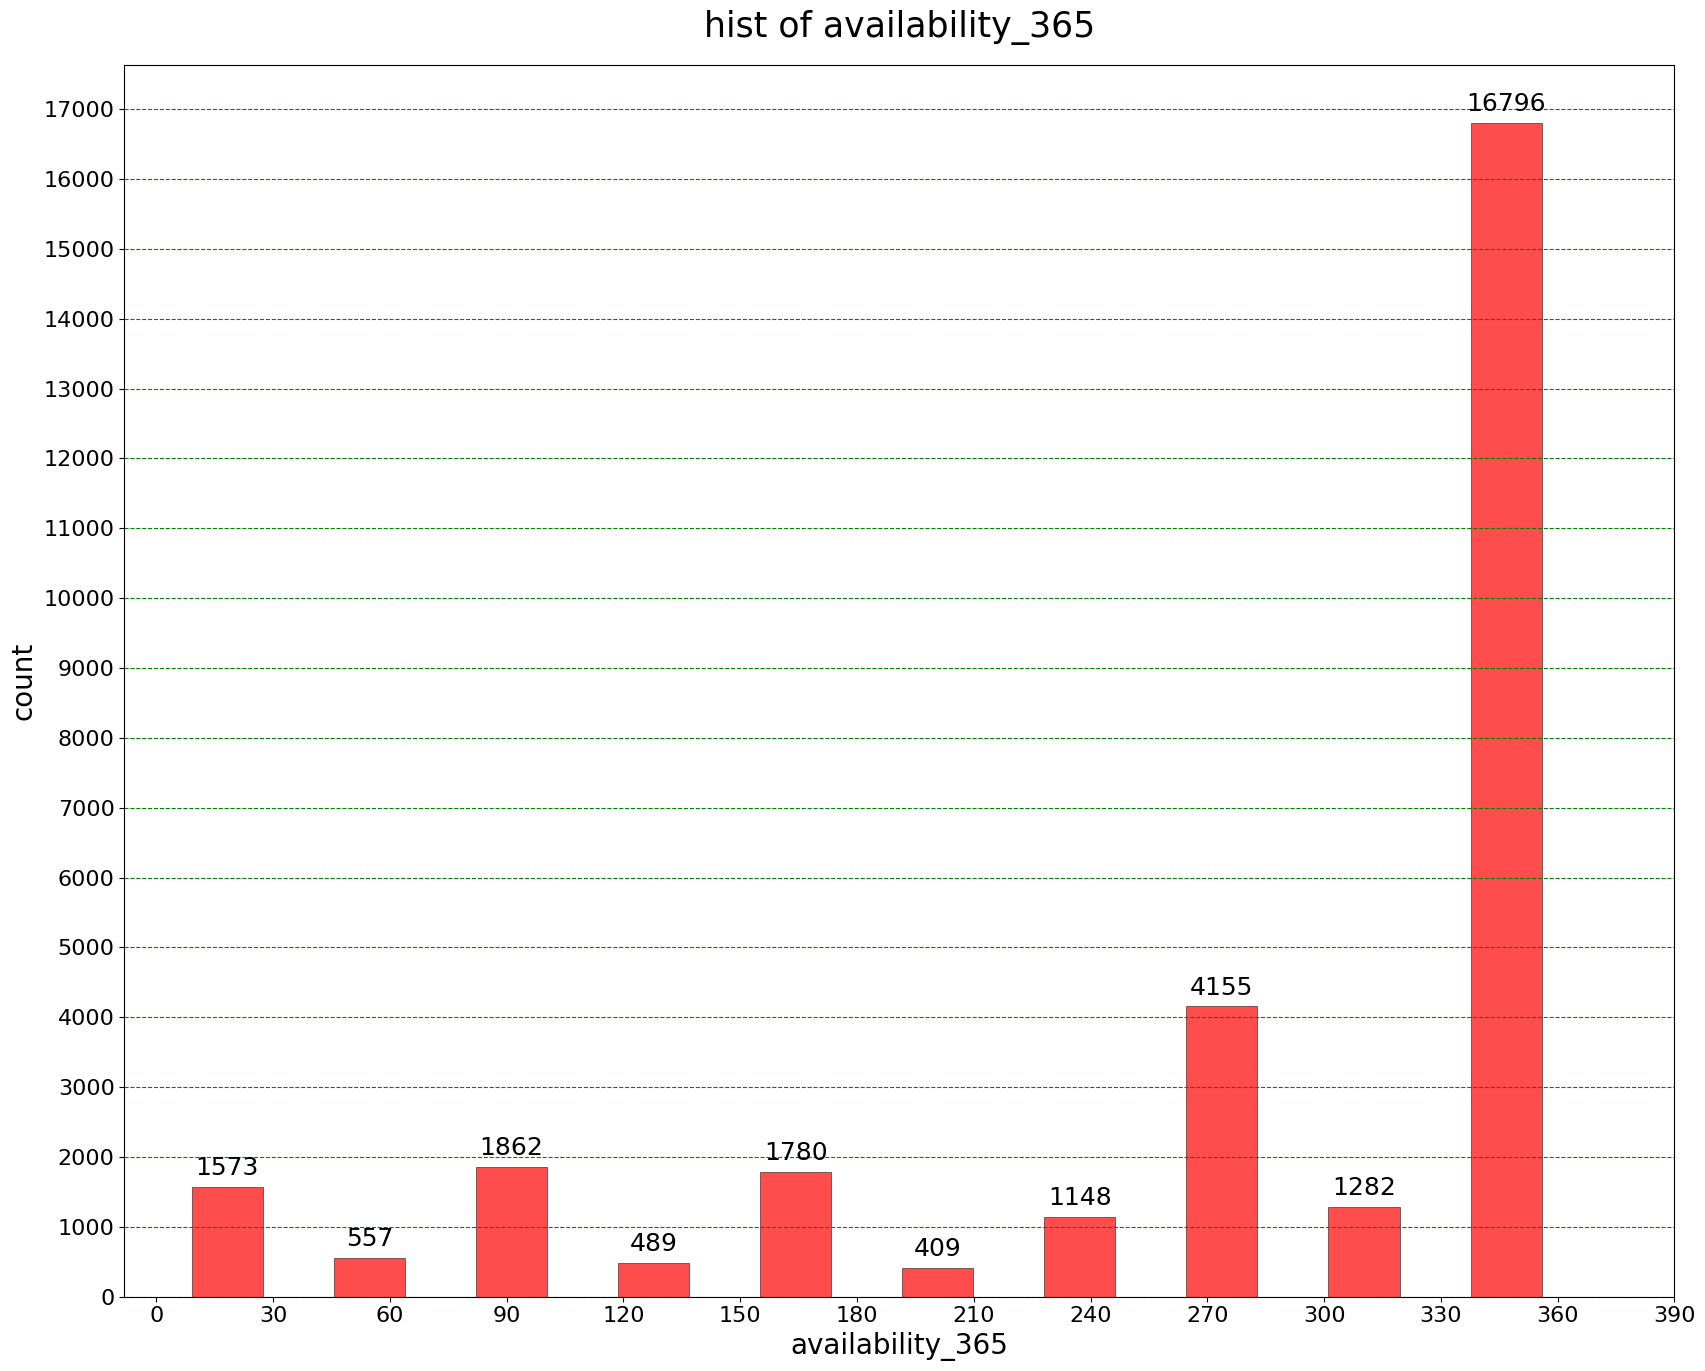

In [30]:
plt.figure(figsize=(20,16))

counts, bins, patches = plt.hist(
    df['availability_365'],
    bins=10,
    edgecolor='black',
    linewidth=0.5,
    color='red',
    alpha=0.7,
    orientation='vertical',
    rwidth=0.5,
    align='mid'
)

# إضافة القيم فوق الأعمدة
for i in range(len(counts)):
    plt.text(
        (bins[i] + bins[i+1]) / 2,   # مركز العمود على محور X
        counts[i] + 100,            # مكان النص فوق العمود بشوية
        str(int(counts[i])),         # القيمة نفسها
        ha='center', va='bottom',
        fontsize=18, color='black'
    )

plt.title('hist of availability_365', fontsize=25, pad=20)
plt.xlabel('availability_365', fontsize=20)
plt.ylabel('count', fontsize=20)
plt.xticks( range(0,400,30),fontsize=16)
plt.yticks(range(0,17500,1000), fontsize=16)
plt.grid(axis='y', linestyle='--', color='green', alpha=1)

plt.show()


Chart Explanation:  
The chart shows the distribution of the number of days a property is available during the year. Most properties are available for very long periods (close to 365 days), while only a few are available for shorter periods. This indicates that most hosts keep their properties open for booking throughout the year rather than for limited times.

In [31]:
df['calculated_host_listings_count'].describe()

count    30051.000000
mean        17.402982
std         49.665718
min          1.000000
25%          1.000000
50%          5.000000
75%         13.000000
max        398.000000
Name: calculated_host_listings_count, dtype: float64

In [32]:
df['reviews_per_month'].value_counts()

reviews_per_month
Unknown    11346
0.04         505
0.03         427
0.05         369
0.06         359
           ...  
6.49           1
4.45           1
6.88           1
7.69           1
7.06           1
Name: count, Length: 714, dtype: int64

In [33]:
df['last_review'].value_counts()

last_review
Unknown       11346
2025-09-14      407
2025-09-28      398
2025-09-21      381
2025-09-15      351
              ...  
2015-01-02        1
2014-08-19        1
2018-07-11        1
2018-08-02        1
2018-09-05        1
Name: count, Length: 1668, dtype: int64

In [34]:
df['number_of_reviews'].describe()

count    30051.000000
mean        18.122725
std         42.911096
min          0.000000
25%          0.000000
50%          2.000000
75%         15.000000
max       1653.000000
Name: number_of_reviews, dtype: float64

In [35]:
df['minimum_nights'].describe()

count    30051.000000
mean        55.441183
std         65.826545
min          1.000000
25%          2.000000
50%         31.000000
75%        100.000000
max       1000.000000
Name: minimum_nights, dtype: float64

In [36]:
df['price'].describe()

count    3.005100e+04
mean     4.676835e+03
std      4.889651e+04
min      8.000000e+01
25%      1.826000e+03
50%      2.538000e+03
75%      3.680000e+03
max      4.437598e+06
Name: price, dtype: float64

In [37]:
df['room_type'].value_counts()

room_type
Entire home/apt    20243
Private room        9494
Shared room          157
Hotel room           157
Name: count, dtype: int64

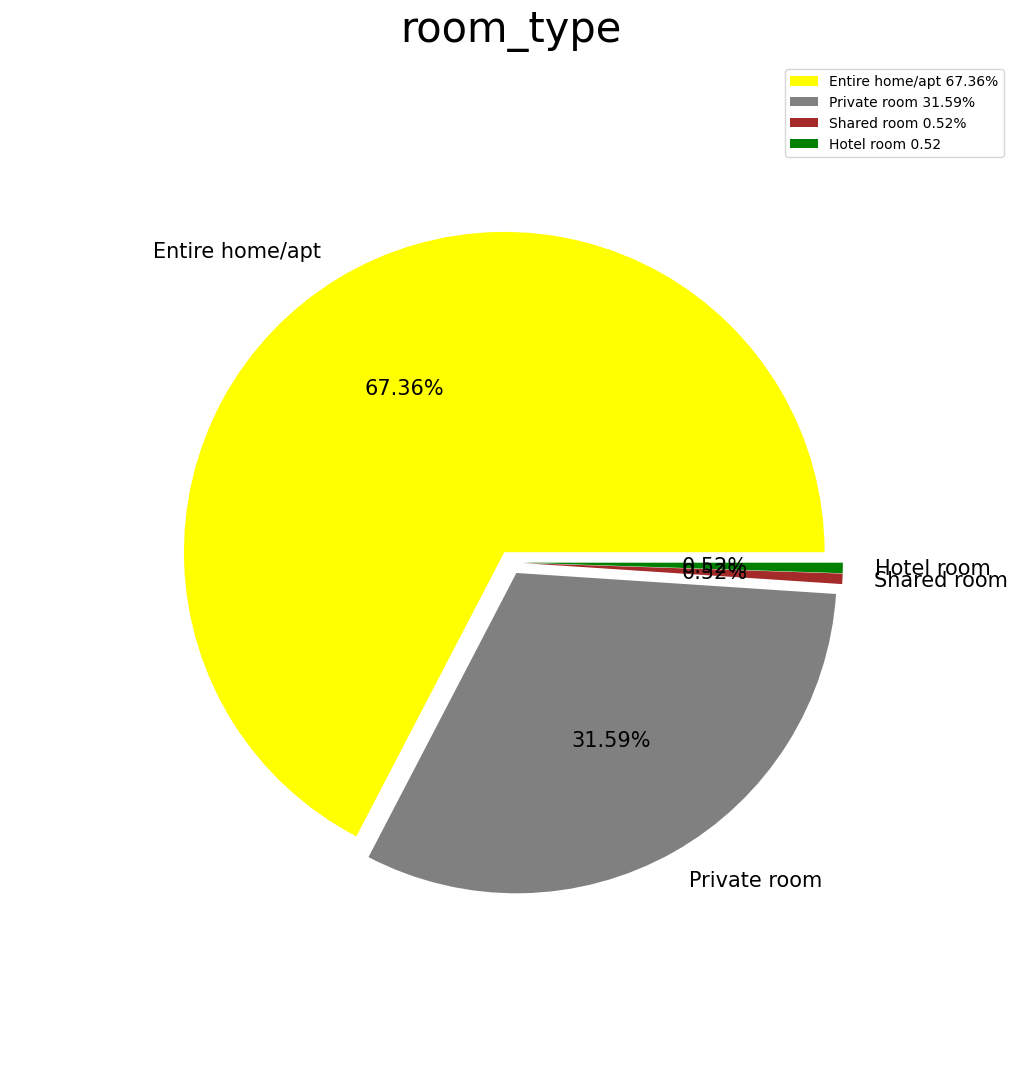

In [38]:
plt.figure(figsize=(16,13))
plt.pie(df['room_type'].value_counts().values,labels=df['room_type'].value_counts().index,colors=['yellow','gray','brown','green'],explode=[0.03,0.03,0.03,0.03],
        autopct='%1.2f%%',shadow=False,radius=0.8,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('room_type',fontsize=30,pad=15)
plt.legend(['Entire home/apt 67.36%','Private room 31.59%','Shared room 0.52%','Hotel room 0.52'])

plt.xticks()
plt.yticks()
plt.show()

Chart Explanation:  

"The chart shows that most listings on the platform are entire homes or apartments (67%), while private rooms make up about 32%. Shared rooms and hotel rooms are very rare, each accounting for less than 1%."

In [39]:
df['longitude'].describe()

count    30051.000000
mean        28.972531
std          0.156914
min         28.007570
25%         28.964309
50%         28.980430
75%         29.005351
max         29.910890
Name: longitude, dtype: float64

In [40]:
df['latitude'].describe()

count    30051.000000
mean        41.029644
std          0.049714
min         40.815237
25%         41.004910
50%         41.031335
75%         41.049397
max         41.486680
Name: latitude, dtype: float64

In [41]:
df['neighbourhood'].value_counts()

neighbourhood
Beyoglu          8046
Fatih            4173
Sisli            3916
Kadikoy          2231
Besiktas         1635
Esenyurt         1129
Bahcelievler      820
Kagithane         731
Uskudar           698
Bagcilar          546
Atasehir          519
Sile              490
Maltepe           402
Basaksehir        347
Bakirkoy          347
Umraniye          346
Avcilar           339
Kucukcekmece      320
Adalar            302
Pendik            296
Arnavutkoy        291
Beylikduzu        259
Sariyer           243
Eyup              234
Kartal            218
Buyukcekmece      181
Beykoz            180
Zeytinburnu       157
Tuzla             116
Gaziosmanpasa     110
Silivri           109
Cekmekoy           80
Gungoren           58
Catalca            37
Bayrampasa         36
Esenler            35
Sancaktepe         33
Sultangazi         21
Sultanbeyli        20
Name: count, dtype: int64

In [42]:
df['host_name'].value_counts()

host_name
Tevfik           420
Murat            409
Mehmet           409
Ali              366
Ahmet            271
                ... 
Asmara             1
Mehmet İkbal       1
Reha               1
Serdar Mehmet      1
Satiye             1
Name: count, Length: 4429, dtype: int64

In [43]:
df['host_id'].describe()

count    3.005100e+04
mean     3.624825e+08
std      2.072839e+08
min      8.592300e+04
25%      1.897019e+08
50%      4.207760e+08
75%      5.159710e+08
max      7.212652e+08
Name: host_id, dtype: float64

In [44]:
df['name'].value_counts()

name
Linkinn Luxury Residence & Spa                 82
Standart Suite in Beyoglu/Taksim               28
Standart Suite in Taksim/Beyoglu               21
Standart Suit in Beyoglu/Kabatas               21
Exclusively Woman - Double Room                20
                                               ..
Bahçe içinde masal gibi ev                      1
Bayrampaşa 5+1 dublex günlük haftalık daire     1
Jakuzili  Maltepe                               1
Midtown Sherine Affleur {3+1}                   1
Geniş bir oda                                   1
Name: count, Length: 28155, dtype: int64

In [45]:
df['id'].describe()

count    3.005100e+04
mean     8.877970e+17
std      4.875416e+17
min      2.543600e+04
25%      6.833662e+17
50%      9.757415e+17
75%      1.289240e+18
max      1.520546e+18
Name: id, dtype: float64

#### **Bivariate Analysis**

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30051 entries, 0 to 30050
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              30051 non-null  int64  
 1   name                            30051 non-null  object 
 2   host_id                         30051 non-null  int64  
 3   host_name                       30051 non-null  object 
 4   neighbourhood                   30051 non-null  object 
 5   latitude                        30051 non-null  float64
 6   longitude                       30051 non-null  float64
 7   room_type                       30051 non-null  object 
 8   price                           30051 non-null  float64
 9   minimum_nights                  30051 non-null  int64  
 10  number_of_reviews               30051 non-null  int64  
 11  last_review                     30051 non-null  object 
 12  reviews_per_month               

# license + price

In [47]:
df.groupby(['license'])['price'].value_counts()

license        price 
+201223983644  2538.0    1
+905052205905  2434.0    1
+905073119677  1600.0    1
+905322907634  3824.0    1
+905375580265  2222.0    1
                        ..
exempt         2609.0    1
               3338.0    1
               3755.0    1
               4172.0    1
Ör.12.8412     8978.0    1
Name: count, Length: 17674, dtype: int64

C:\Users\Mega\AppData\Local\Temp\ipykernel_10760\2866976818.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


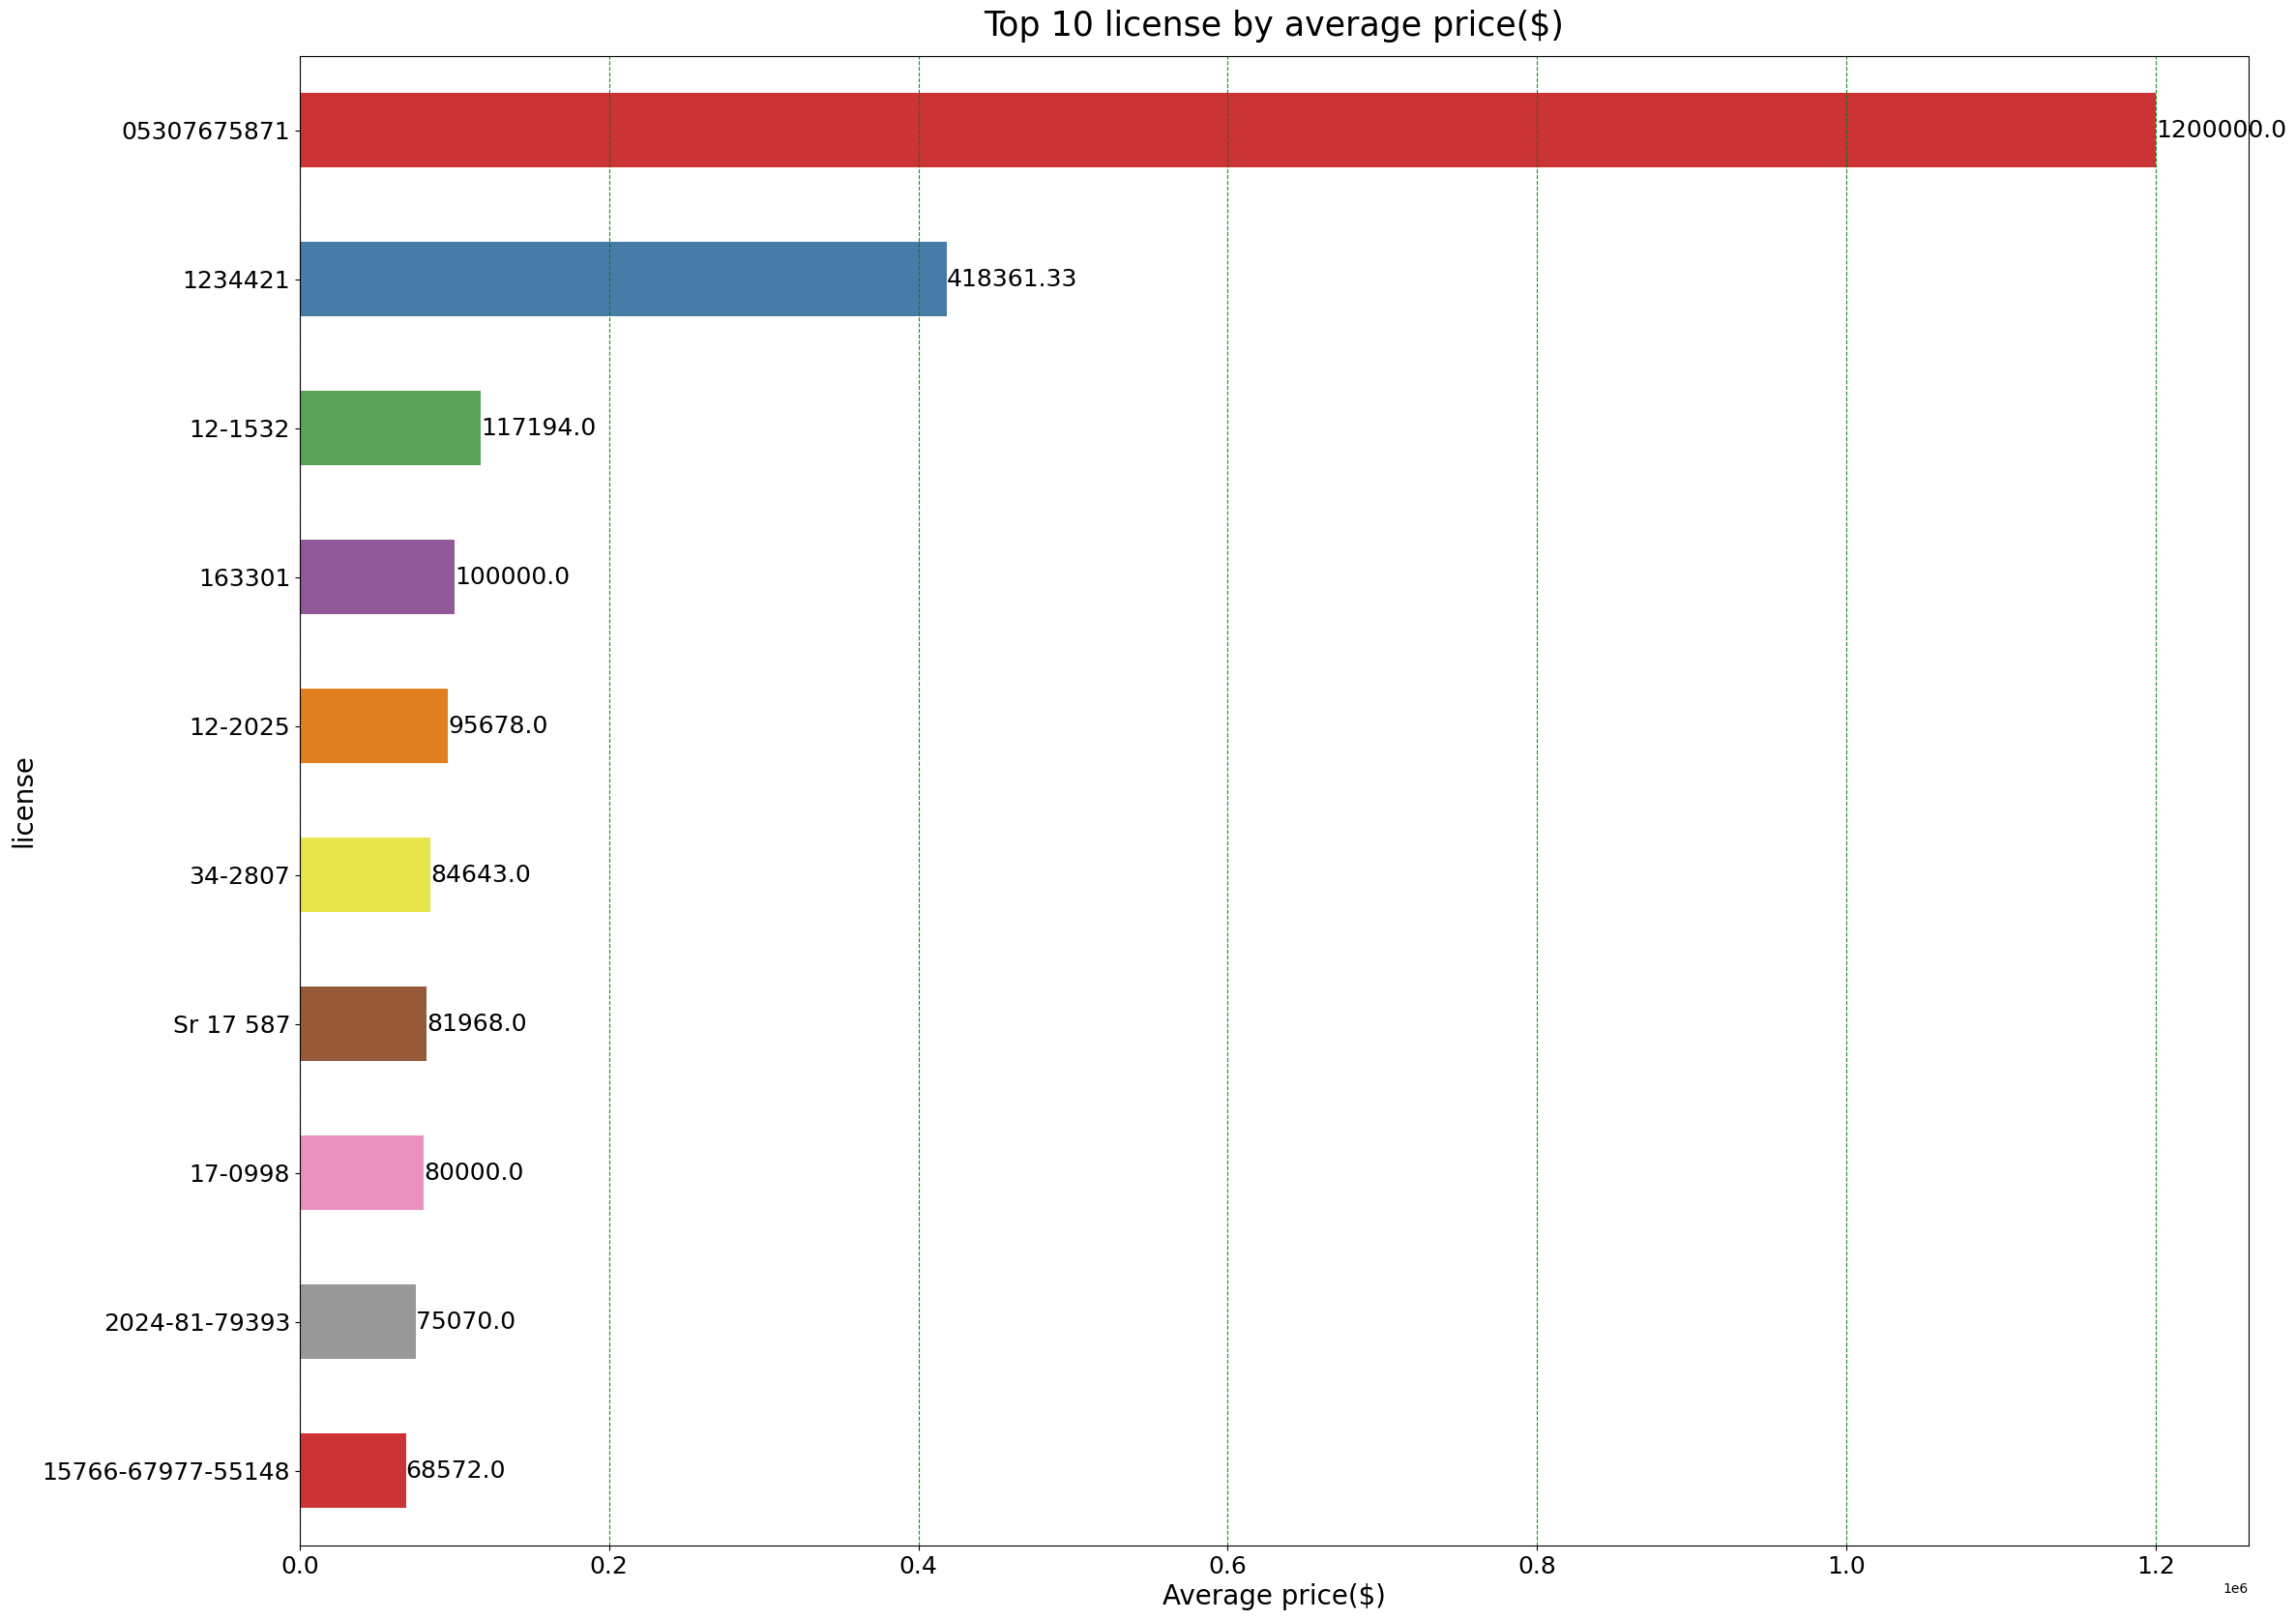

In [48]:


# حساب المتوسط للسعر لكل حي
top10 = df.groupby('license')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(26,20))
ax = sns.barplot(
    x=top10.values, 
    y=top10.index, 
    palette='Set1',width=0.5
)

# إضافة القيم فوق الأعمدة
for i, v in enumerate(top10.values):
    ax.text(v + 50, i, round(v, 2), va='center', fontsize=18, color='black')

# تحسينات الشكل
plt.title("Top 10 license by average price($)", fontsize=25, pad=15)
plt.xlabel('Average price($)', fontsize=20)
plt.ylabel('license', fontsize=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.grid(axis='x', linestyle='--', color='green', alpha=0.9)

plt.show()


Chart Explanation:  

"The chart shows the top 10 licenses by average price in dollars. License 05307675871 clearly leads the list with a much higher average price (around $1.2 million), while the other licenses are significantly lower and gradually decrease down to about $68,000."

# neighbourhood + price

In [49]:
df.groupby(['neighbourhood'])['price'].value_counts()

neighbourhood  price  
Adalar         2538.0     70
               7715.0      4
               4591.0      3
               1500.0      2
               2010.0      2
                          ..
Zeytinburnu    7784.0      1
               7984.0      1
               8000.0      1
               8762.0      1
               16000.0     1
Name: count, Length: 15982, dtype: int64

C:\Users\Mega\AppData\Local\Temp\ipykernel_10760\4009460647.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


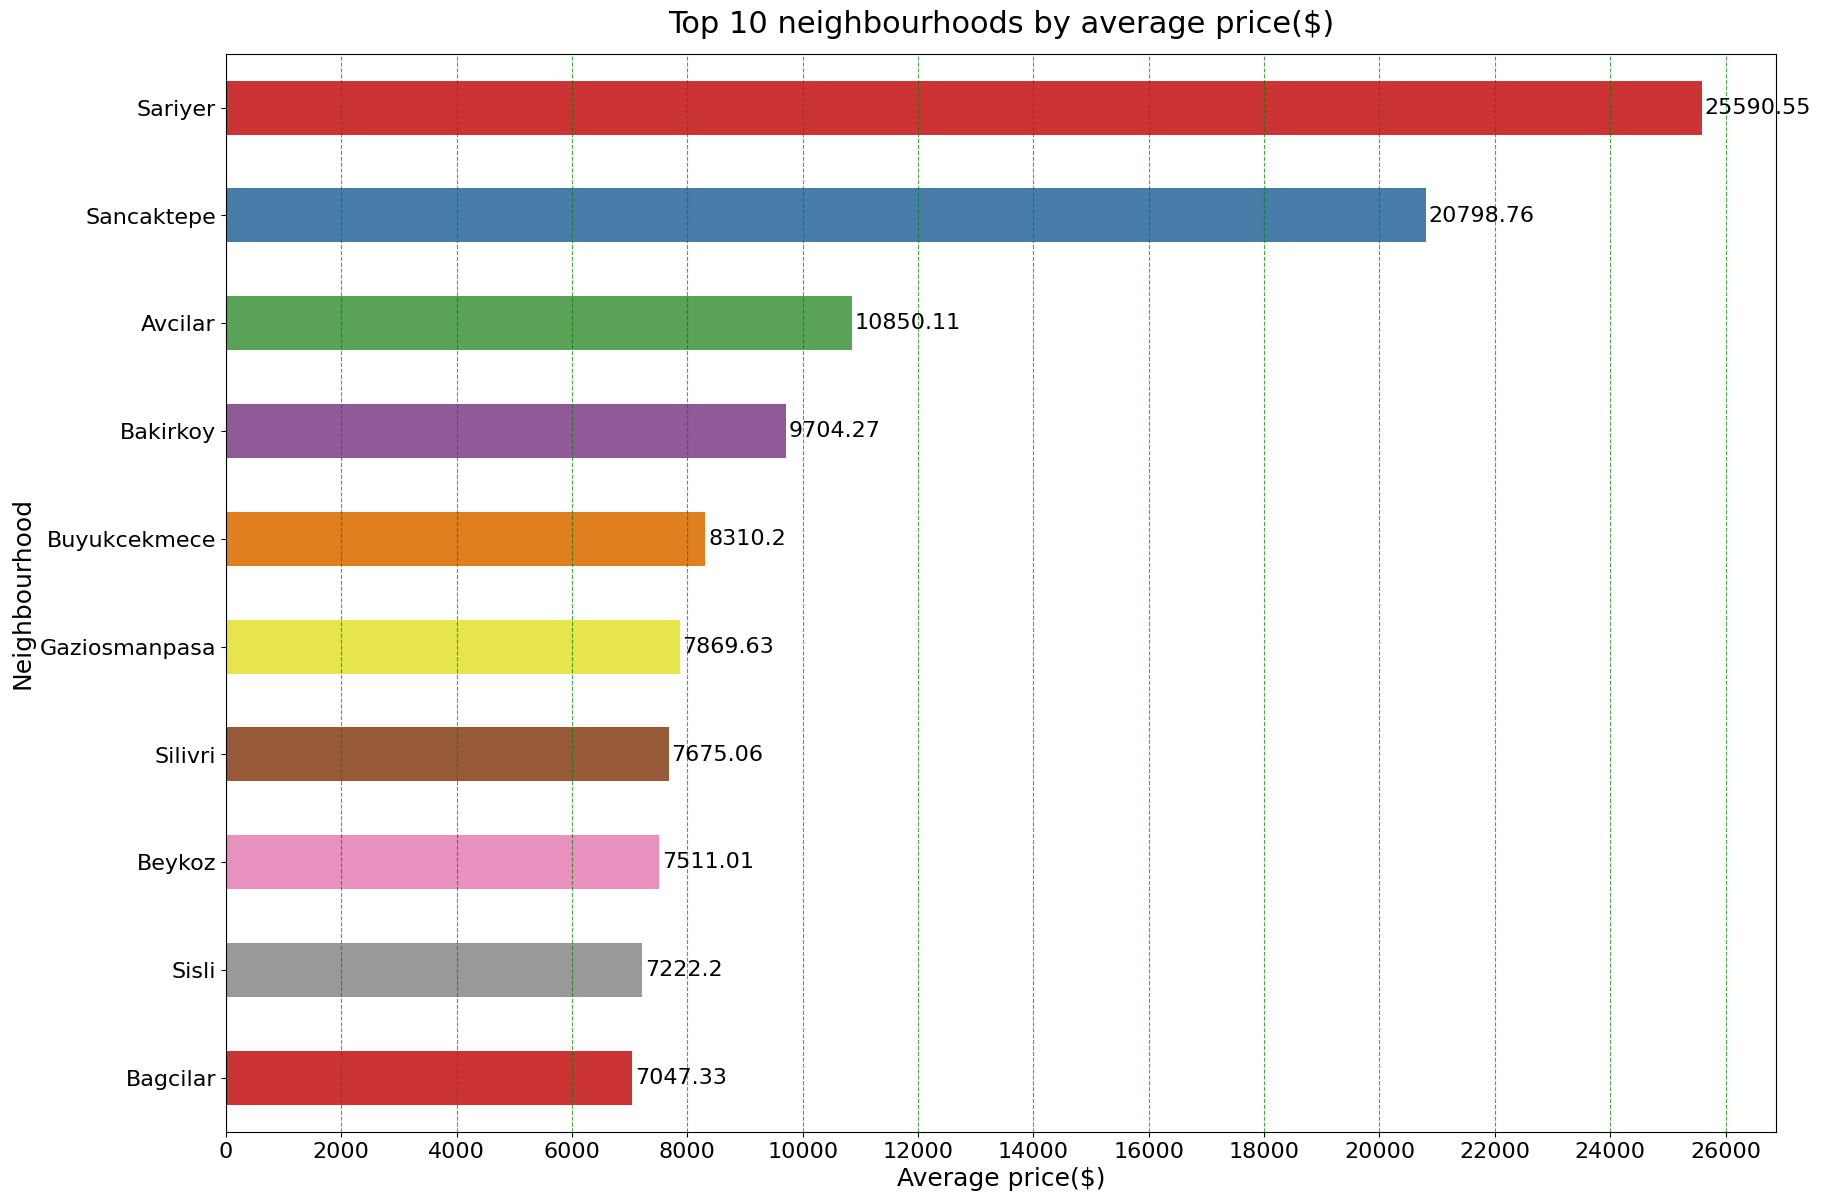

In [50]:


# حساب المتوسط للسعر لكل حي
top10 = df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(20,14))
ax = sns.barplot(
    x=top10.values, 
    y=top10.index, 
    palette='Set1',width=0.5
)

# إضافة القيم فوق الأعمدة
for i, v in enumerate(top10.values):
    ax.text(v + 50, i, round(v, 2), va='center', fontsize=16, color='black')

# تحسينات الشكل
plt.title("Top 10 neighbourhoods by average price($)", fontsize=22, pad=15)
plt.xlabel('Average price($)', fontsize=18)
plt.ylabel('Neighbourhood', fontsize=18)

plt.xticks(range(0,28000,2000),fontsize=16)
plt.yticks(fontsize=16)

plt.grid(axis='x', linestyle='--', color='green', alpha=0.7)

plt.show()


Chart Explanation:  

"The chart shows the top 10 neighborhoods by average price in dollars. Sarıyer leads the list with about $25,590, followed by Sancaktepe with around $20,799, while the other neighborhoods are much lower and gradually decrease until reaching about $7,000 in Bağcılar."

# room_type + price

In [51]:
df.groupby(['room_type'])['price'].value_counts()

room_type        price 
Entire home/apt  2538.0    2174
                 2000.0     123
                 1500.0      82
                 2500.0      82
                 3000.0      72
                           ... 
Shared room      5429.0       1
                 5600.0       1
                 5841.0       1
                 6086.0       1
                 7221.0       1
Name: count, Length: 8578, dtype: int64

C:\Users\Mega\AppData\Local\Temp\ipykernel_10760\2041839907.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=df, x='room_type', y='price', ci=None, palette='Set2',width=0.4)
C:\Users\Mega\AppData\Local\Temp\ipykernel_10760\2041839907.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='room_type', y='price', ci=None, palette='Set2',width=0.4)


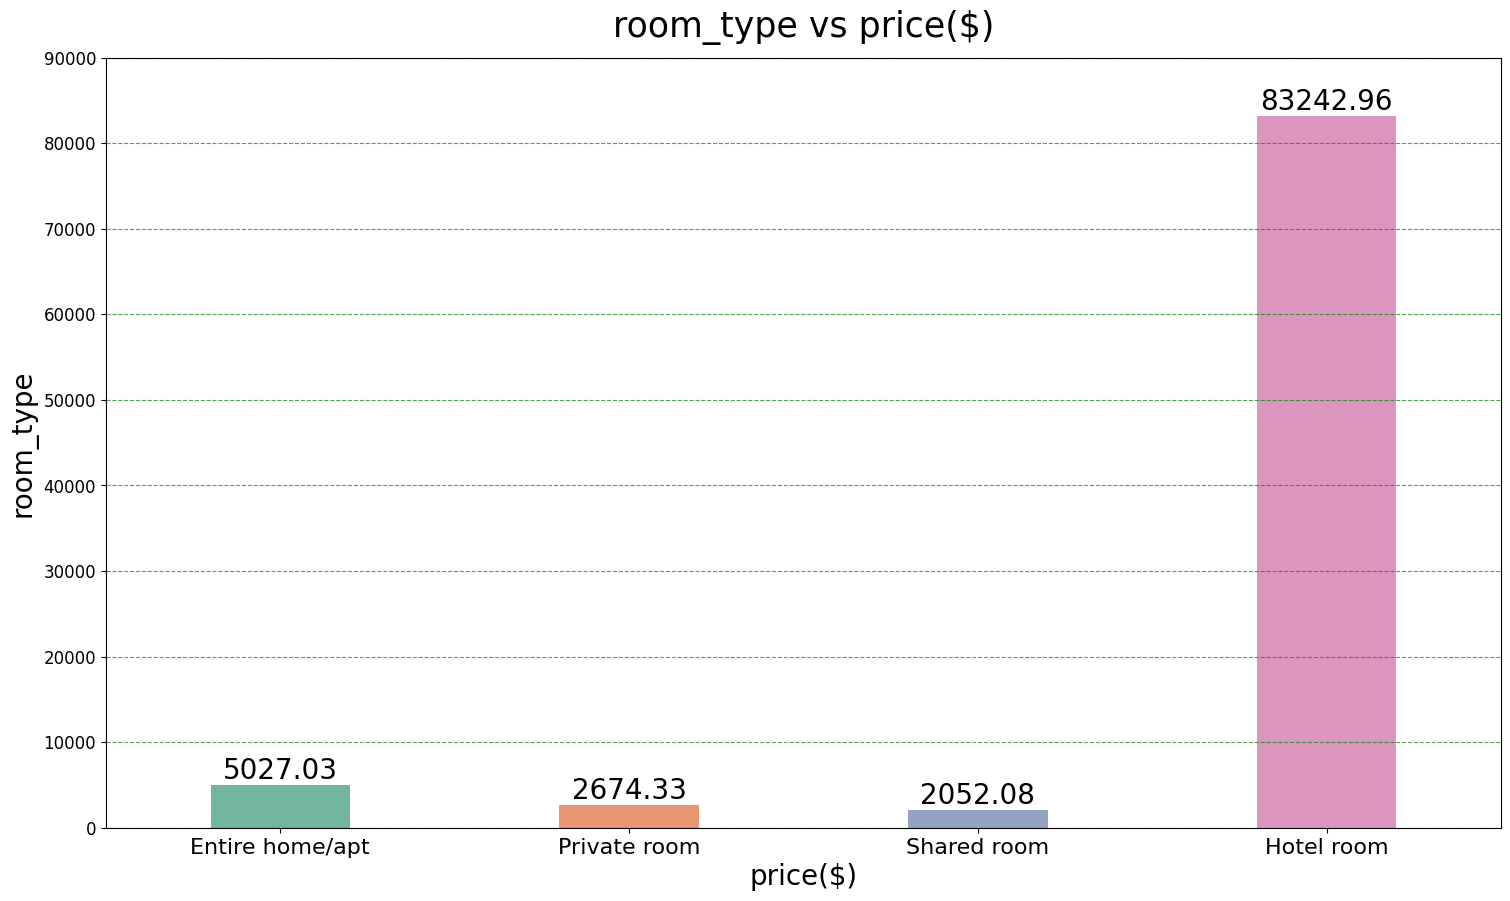

In [52]:
plt.figure(figsize=(18,10))  
ax = sns.barplot(data=df, x='room_type', y='price', ci=None, palette='Set2',width=0.4)
# إضافة القيم فوق الأعمدة
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width()/2,   # مركز العمود على محور X
        p.get_height() + 0.01,          # مكان النص فوق العمود بشوية
        round(p.get_height(), 2),      # القيمة نفسها (مقربة لـ 2 رقم عشري)
        ha='center', va='bottom',
        fontsize=20, color='black'
    )

# تحسينات الشكل
plt.title("room_type vs price($)", fontsize=25, pad=15)
plt.xlabel('price($)', fontsize=20)
plt.ylabel('room_type', fontsize=20)

plt.xticks(fontsize=16)
plt.yticks(range(0,100000,10000),fontsize=12)



# شبكة رأسية للتوضيح
plt.grid(axis='y', linestyle='--', color='green', alpha=0.7)

plt.show()

Chart Explanation:  

"The chart shows the average prices by room type. Hotel rooms are much more expensive (around $83,243), while entire apartments come second at about $5,027, and private and shared rooms are much cheaper."

# multivariate analysis

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30051 entries, 0 to 30050
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              30051 non-null  int64  
 1   name                            30051 non-null  object 
 2   host_id                         30051 non-null  int64  
 3   host_name                       30051 non-null  object 
 4   neighbourhood                   30051 non-null  object 
 5   latitude                        30051 non-null  float64
 6   longitude                       30051 non-null  float64
 7   room_type                       30051 non-null  object 
 8   price                           30051 non-null  float64
 9   minimum_nights                  30051 non-null  int64  
 10  number_of_reviews               30051 non-null  int64  
 11  last_review                     30051 non-null  object 
 12  reviews_per_month               

# Corrlation

In [54]:
df[['id','host_id','latitude','longitude','price','minimum_nights','number_of_reviews','calculated_host_listings_count',
         'availability_365','number_of_reviews_ltm']].corr()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,number_of_reviews_ltm
id,1.000000,0.471019,0.020467,-0.033578,0.001362,-0.217399,-0.348998,0.070174,0.033995,-0.037636
host_id,0.471019,1.000000,0.021260,-0.056736,0.001991,0.003722,-0.255248,-0.198615,0.085477,-0.100857
latitude,0.020467,0.021260,1.000000,-0.070748,0.021508,0.011214,-0.042080,0.020929,0.010360,-0.043633
longitude,-0.033578,-0.056736,-0.070748,1.000000,0.000818,-0.007360,0.038586,-0.039454,-0.059230,0.039546
price,0.001362,0.001991,0.021508,0.000818,1.000000,0.003184,-0.006343,-0.001253,-0.002526,-0.010317
minimum_nights,-0.217399,0.003722,0.011214,-0.007360,0.003184,1.000000,-0.201933,-0.149728,0.041284,-0.309779
number_of_reviews,-0.348998,-0.255248,-0.042080,0.038586,-0.006343,-0.201933,1.000000,-0.021588,-0.075559,0.688305
calculated_host_listings_count,0.070174,-0.198615,0.020929,-0.039454,-0.001253,-0.149728,-0.021588,1.000000,-0.163083,-0.001515
availability_365,0.033995,0.085477,0.010360,-0.059230,-0.002526,0.041284,-0.075559,-0.163083,1.000000,-0.088819
number_of_reviews_ltm,-0.037636,-0.100857,-0.043633,0.039546,-0.010317,-0.309779,0.688305,-0.001515,-0.088819,1.000000


In [55]:
corr=df[['id','host_id','latitude','longitude','price','minimum_nights','number_of_reviews','calculated_host_listings_count',
         'availability_365','number_of_reviews_ltm']].corr()


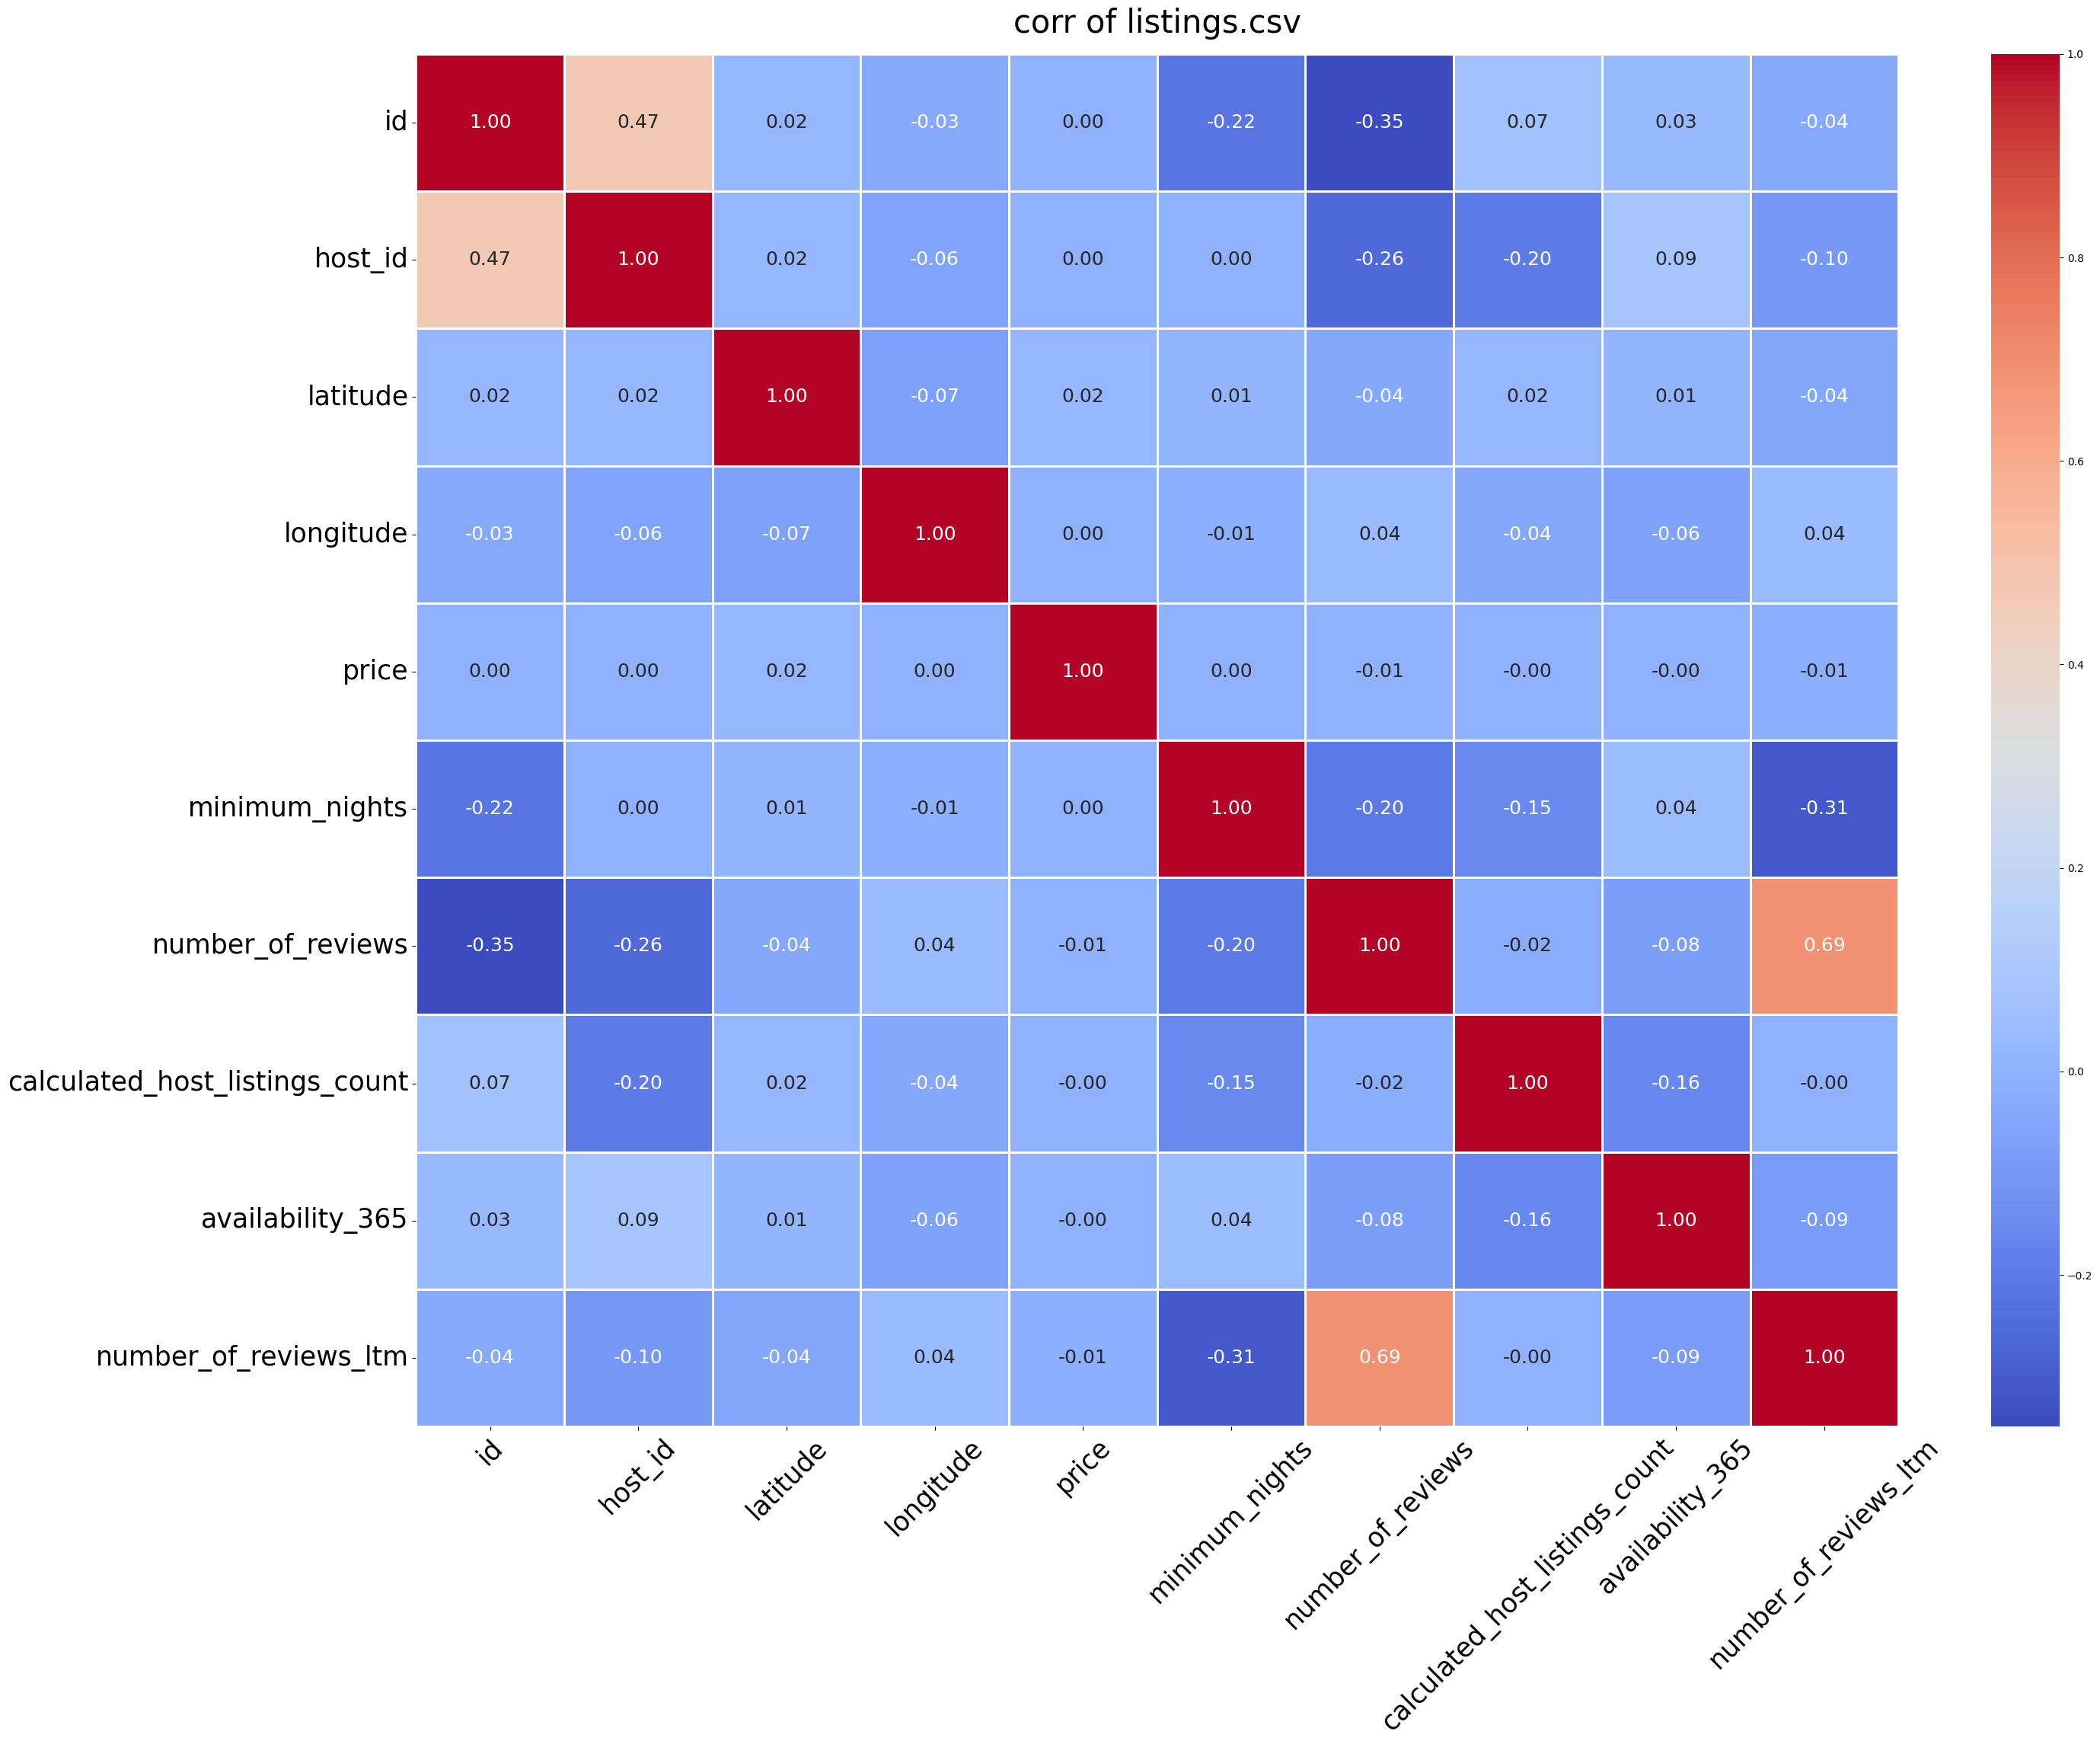

In [56]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(30,23))
sns.heatmap(corr,cmap='coolwarm',annot=True,edgecolor='yellow',linewidths=0.8,fmt='.2f',annot_kws={"size": 18})
plt.title('corr of listings.csv',fontsize=30,pad=20)
plt.xticks(rotation=45,fontsize=25)
plt.yticks(rotation=0,fontsize=25)

plt.tight_layout()
plt.show()



Chart Explanation:  

"The chart shows the relationships between variables in the listings data. We can see that the number of reviews is strongly correlated with the number of reviews in the last 12 months, while there are negative correlations between minimum nights and the number of reviews. Overall, the heatmap helps to understand how different features interact with each other."

# number_of_reviews + number_of_reviews_ltm + price

In [57]:
df[['number_of_reviews','number_of_reviews_ltm','price']].corr()

,number_of_reviews,number_of_reviews_ltm,price
number_of_reviews,1.000000,0.688305,-0.006343
number_of_reviews_ltm,0.688305,1.000000,-0.010317
price,-0.006343,-0.010317,1.000000


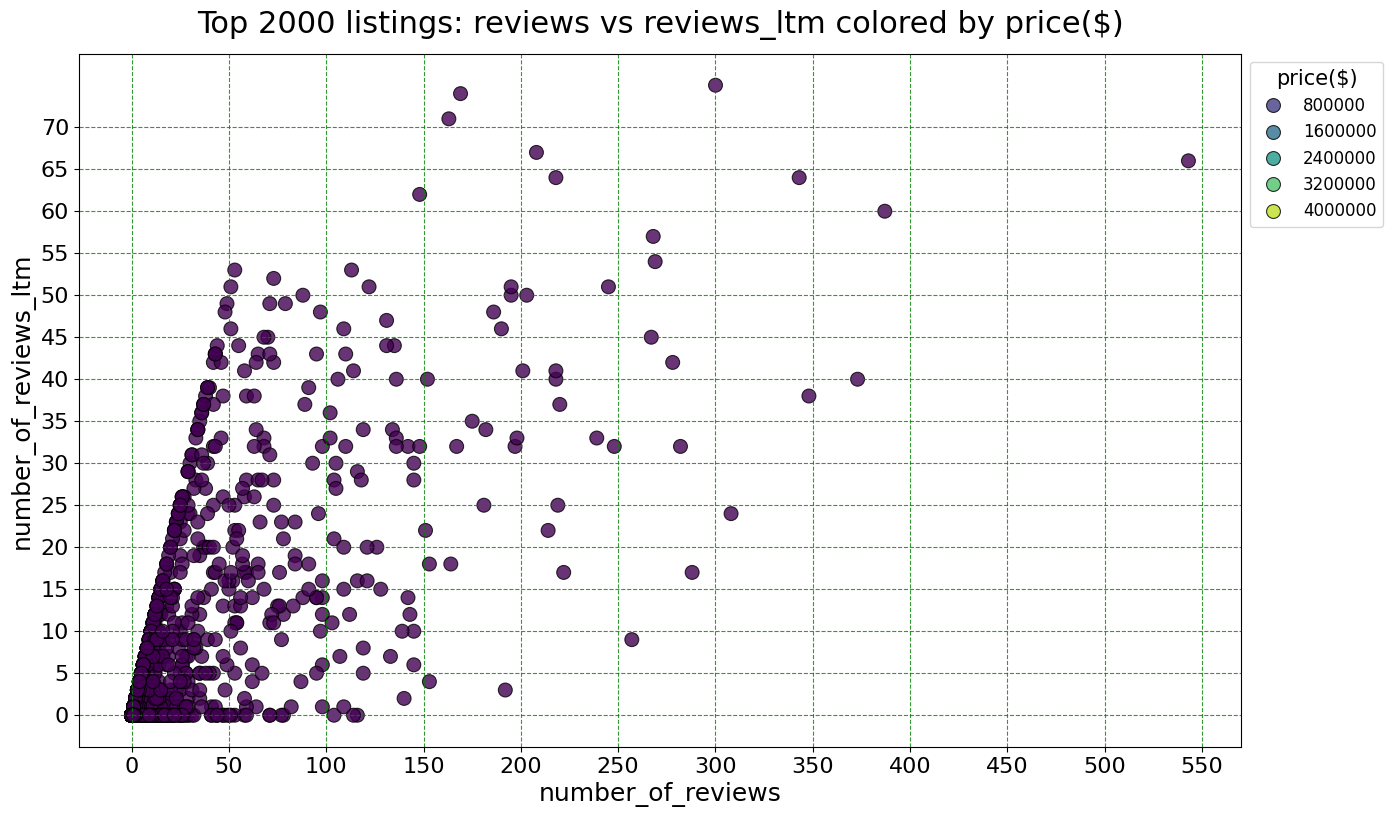

In [58]:


# اختيار أعلى 2000 حسب السعر
top2000 = df.nlargest(2000, 'price')

plt.figure(figsize=(15,9))
sns.scatterplot(
    x='number_of_reviews',
    y='number_of_reviews_ltm',
    hue='price',
    palette='viridis',
    data=top2000,
    s=100, alpha=0.8, edgecolor='black')

plt.title('Top 2000 listings: reviews vs reviews_ltm colored by price($)', fontsize=22, pad=15)
plt.xlabel('number_of_reviews', fontsize=18)
plt.ylabel('number_of_reviews_ltm', fontsize=18)
plt.legend(title='price($)', title_fontsize=15, fontsize=12, bbox_to_anchor=(1,1))
plt.xticks(range(0,600,50), fontsize=16)
plt.yticks(range(0,75,5), fontsize=16)

plt.grid(True, linestyle='--',color='green', alpha=0.8)
plt.show()


Chart Explanation:  

"The chart shows the relationship between the total number of reviews and recent reviews for the top 2000 listings. Most listings have fewer than 100 total reviews and fewer than 50 recent reviews, with some exceptional cases. The colors represent prices, highlighting significant differences among the listings."

C:\Users\Mega\AppData\Local\Temp\ipykernel_10760\733128343.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='Set1', width=0.5, ax=ax3)
C:\Users\Mega\AppData\Local\Temp\ipykernel_10760\733128343.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='Set1', width=0.5, ax=ax4)
C:\Users\Mega\AppData\Local\Temp\ipykernel_10760\733128343.py:66: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='room_type', y='price', ci=None, palette='Set2', width=0.4, ax=ax5)
C:\Users\Mega\AppData\Local\Temp\ipykernel_10760\733128343.py:66: FutureWarning: 

Passing

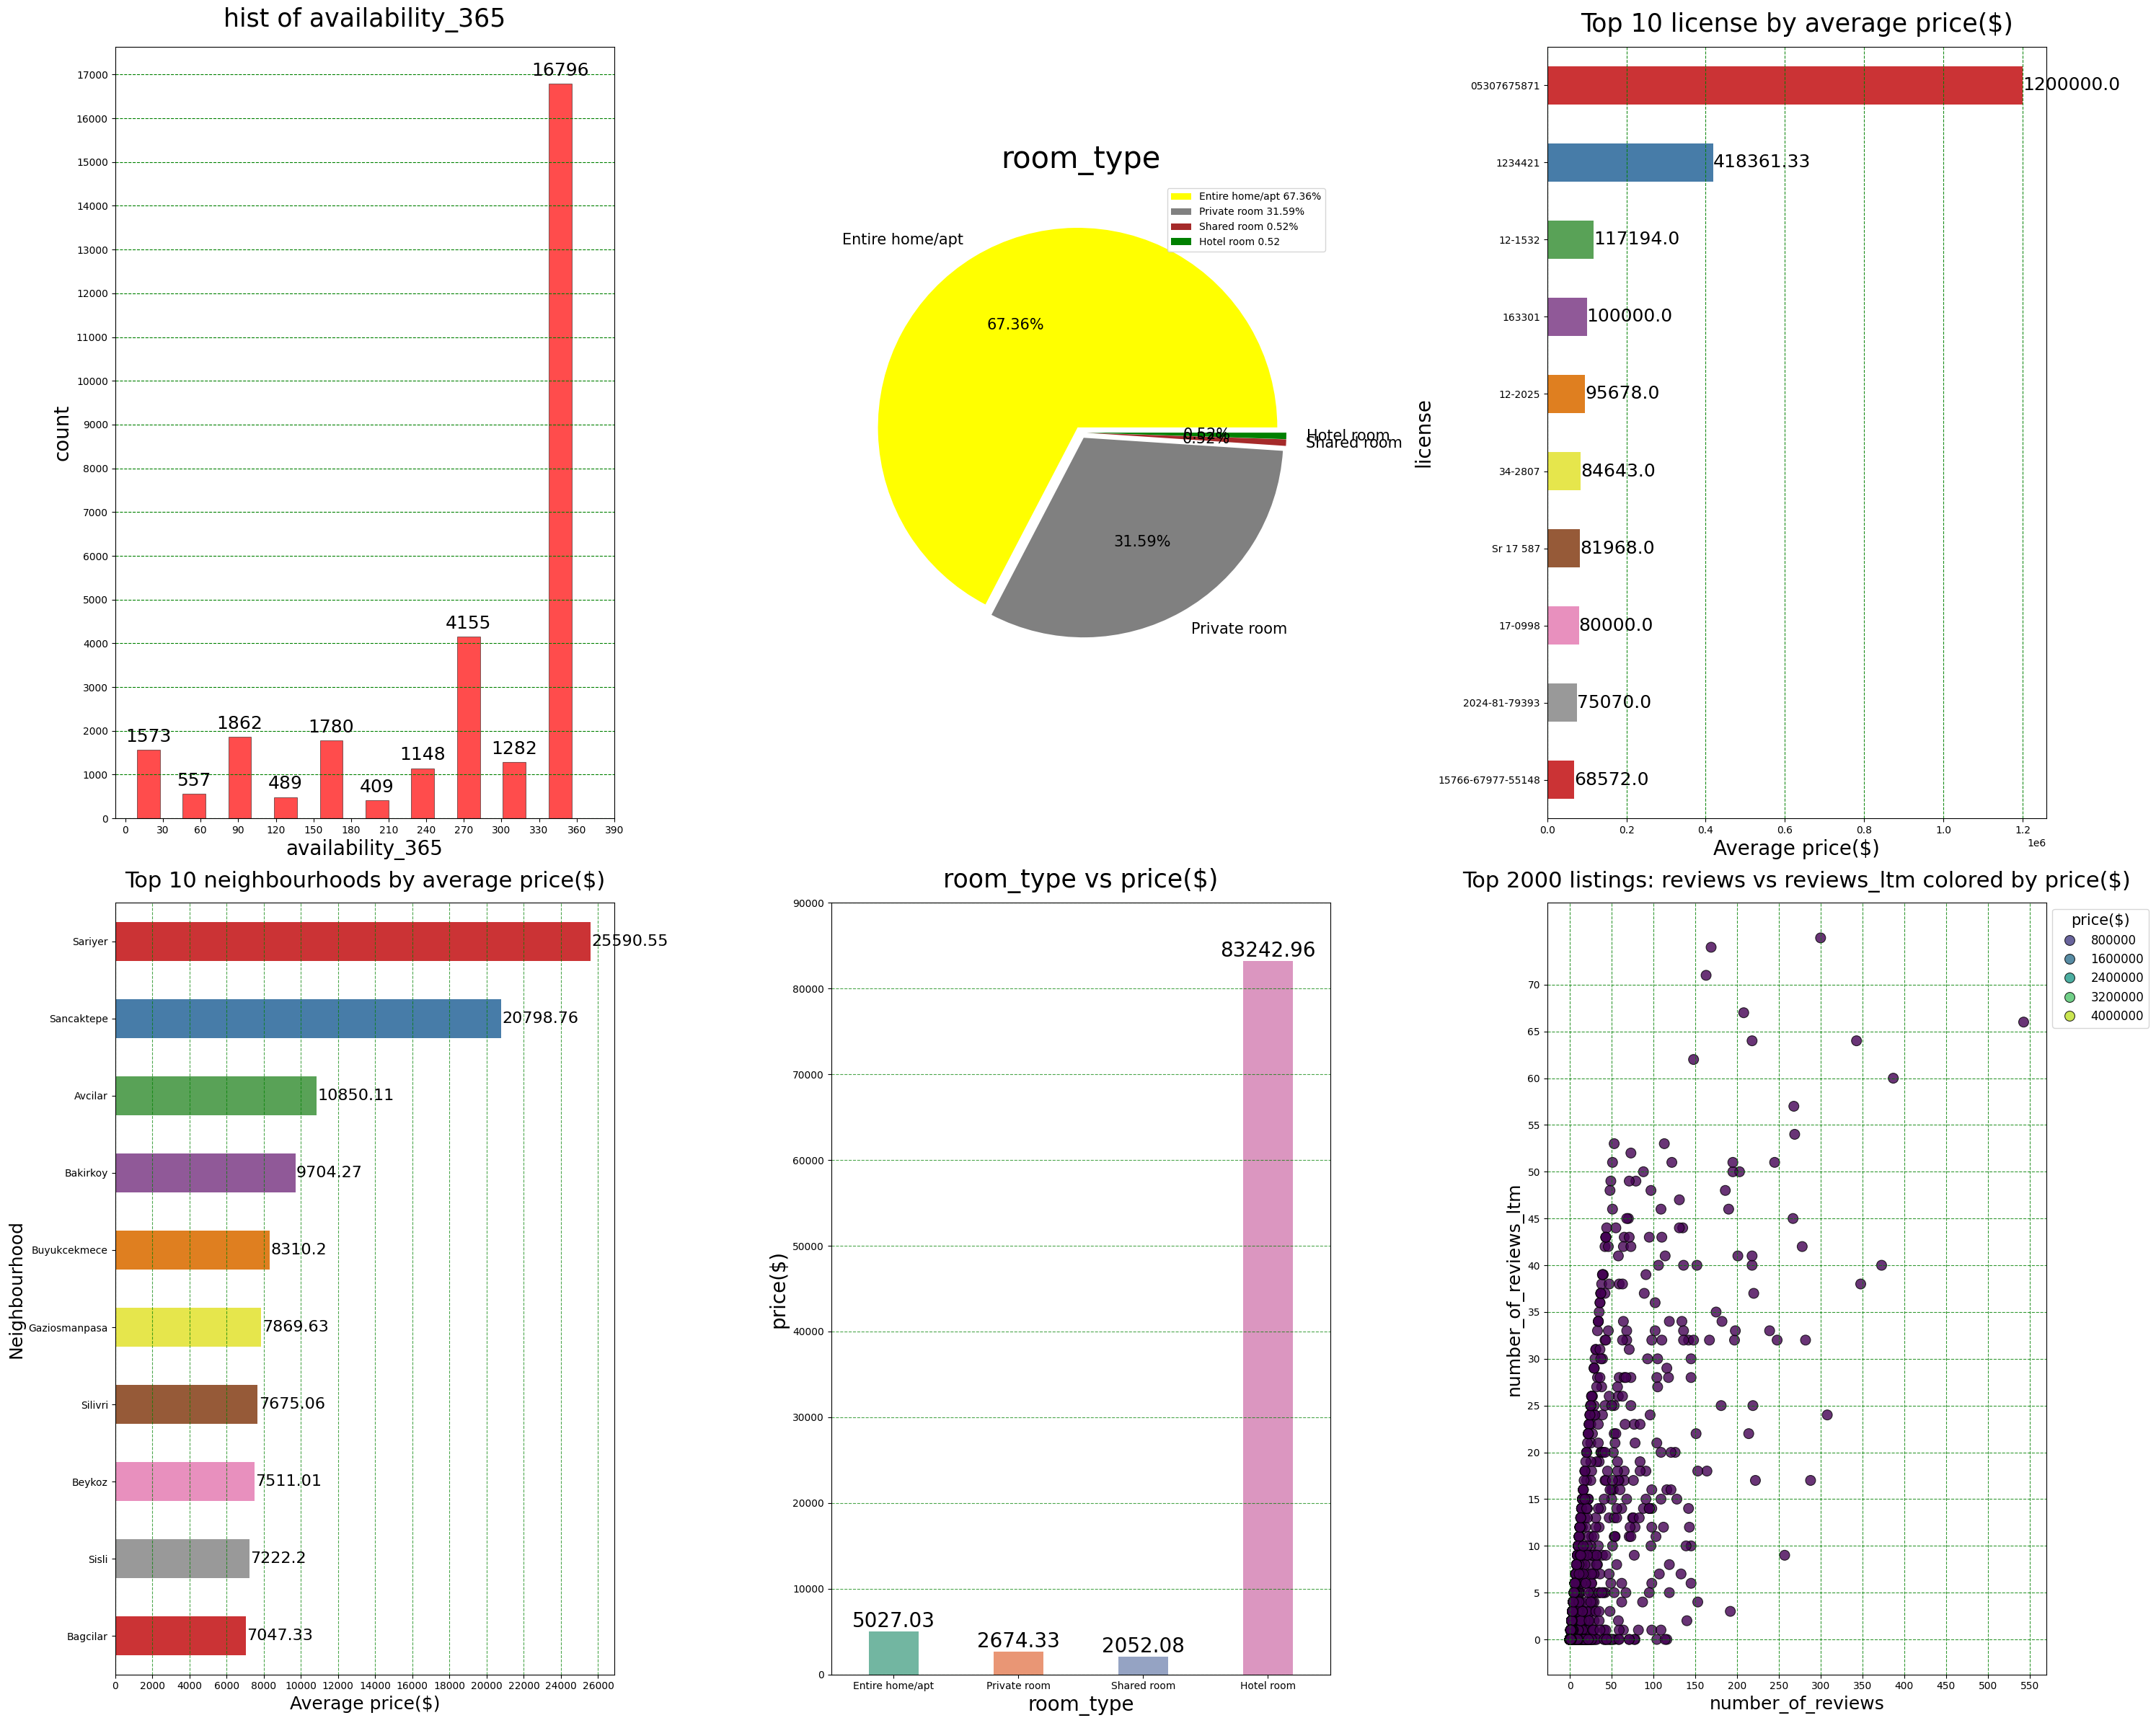

In [59]:


fig, axes = plt.subplots(2, 3, figsize=(30, 24))

# subplot 1: hist of availability_365

ax1 = axes[0,0]
counts, bins, patches = ax1.hist(
    df['availability_365'],
    bins=10,
    edgecolor='black',
    linewidth=0.5,
    color='red',
    alpha=0.7,
    rwidth=0.5,
    align='mid'
)
for i in range(len(counts)):
    ax1.text((bins[i] + bins[i+1]) / 2, counts[i] + 100, str(int(counts[i])),
             ha='center', va='bottom', fontsize=18, color='black')
ax1.set_title('hist of availability_365', fontsize=25, pad=20)
ax1.set_xlabel('availability_365', fontsize=20)
ax1.set_ylabel('count', fontsize=20)
ax1.set_xticks(range(0,400,30))
ax1.set_yticks(range(0,17500,1000))
ax1.grid(axis='y', linestyle='--', color='green', alpha=1)

# subplot 2: pie of room_type

ax2 = axes[0,1]
ax2.pie(df['room_type'].value_counts().values,
        labels=df['room_type'].value_counts().index,
        colors=['yellow','gray','brown','green'],
        explode=[0.03,0.03,0.03,0.03],
        autopct='%1.2f%%',
        textprops={'fontsize':15})
ax2.set_title('room_type', fontsize=30, pad=15)
ax2.legend(['Entire home/apt 67.36%','Private room 31.59%','Shared room 0.52%','Hotel room 0.52'])

# subplot 3: Top 10 license by average price($)

ax3 = axes[0,2]
top10 = df.groupby('license')['price'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top10.values, y=top10.index, palette='Set1', width=0.5, ax=ax3)
for i, v in enumerate(top10.values):
    ax3.text(v + 50, i, round(v, 2), va='center', fontsize=18, color='black')
ax3.set_title("Top 10 license by average price($)", fontsize=25, pad=15)
ax3.set_xlabel('Average price($)', fontsize=20)
ax3.set_ylabel('license', fontsize=20)
ax3.grid(axis='x', linestyle='--', color='green', alpha=0.9)

# subplot 4: Top 10 neighbourhoods by average price($)

ax4 = axes[1,0]
top10 = df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top10.values, y=top10.index, palette='Set1', width=0.5, ax=ax4)
for i, v in enumerate(top10.values):
    ax4.text(v + 50, i, round(v, 2), va='center', fontsize=16, color='black')
ax4.set_title("Top 10 neighbourhoods by average price($)", fontsize=22, pad=15)
ax4.set_xlabel('Average price($)', fontsize=18)
ax4.set_ylabel('Neighbourhood', fontsize=18)
ax4.set_xticks(range(0,28000,2000))
ax4.grid(axis='x', linestyle='--', color='green', alpha=0.7)

# subplot 5: room_type vs price($)

ax5 = axes[1,1]
sns.barplot(data=df, x='room_type', y='price', ci=None, palette='Set2', width=0.4, ax=ax5)
for p in ax5.patches:
    ax5.text(p.get_x() + p.get_width()/2, p.get_height() + 0.01,
             round(p.get_height(), 2), ha='center', va='bottom',
             fontsize=20, color='black')
ax5.set_title("room_type vs price($)", fontsize=25, pad=15)
ax5.set_xlabel('room_type', fontsize=20)
ax5.set_ylabel('price($)', fontsize=20)
ax5.set_yticks(range(0,100000,10000))
ax5.grid(axis='y', linestyle='--', color='green', alpha=0.7)

# subplot 6: Top 2000 listings scatter

ax6 = axes[1,2]
top2000 = df.nlargest(2000, 'price')
sns.scatterplot(x='number_of_reviews', y='number_of_reviews_ltm',
                hue='price', palette='viridis', data=top2000,
                s=100, alpha=0.8, edgecolor='black', ax=ax6)
ax6.set_title('Top 2000 listings: reviews vs reviews_ltm colored by price($)', fontsize=22, pad=15)
ax6.set_xlabel('number_of_reviews', fontsize=18)
ax6.set_ylabel('number_of_reviews_ltm', fontsize=18)
ax6.legend(title='price($)', title_fontsize=15, fontsize=12, bbox_to_anchor=(1,1))
ax6.set_xticks(range(0,600,50))
ax6.set_yticks(range(0,75,5))
ax6.grid(True, linestyle='--', color='green', alpha=0.8)

plt.tight_layout()
plt.show()


Chart Explanation:  

"The chart presents a set of indicators about Airbnb listings: the distribution of room types, the licenses and neighborhoods with the highest average prices, as well as a comparison of prices by room type. It also shows the relationship between the total number of reviews and recent reviews for the top 2000 listings. Overall, the visualizations reveal that most listings are entire apartments, with significant variation in prices across neighborhoods and licenses, along with some exceptional cases in both prices and reviews."

#### **Drop Unneeded Columns**

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30051 entries, 0 to 30050
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              30051 non-null  int64  
 1   name                            30051 non-null  object 
 2   host_id                         30051 non-null  int64  
 3   host_name                       30051 non-null  object 
 4   neighbourhood                   30051 non-null  object 
 5   latitude                        30051 non-null  float64
 6   longitude                       30051 non-null  float64
 7   room_type                       30051 non-null  object 
 8   price                           30051 non-null  float64
 9   minimum_nights                  30051 non-null  int64  
 10  number_of_reviews               30051 non-null  int64  
 11  last_review                     30051 non-null  object 
 12  reviews_per_month               

In [61]:
df.drop(columns=['id','name','host_id','host_name','license'],inplace=True)


dentifiers (id, host_id): These are just unique labels. They don’t describe the property or affect its price.

Names (name, host_name): Text fields with little structured meaning. They vary widely and don’t provide consistent signals for prediction.

License: Administrative or categorical codes that usually don’t influence price directly.

In [62]:
df

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,Fatih,41.031098,28.945879,Entire home/apt,2290.0,5,4,2025-09-19,0.58,2,180,4
1,Beyoglu,41.038460,28.983504,Private room,1101.0,7,4,2025-09-02,0.67,7,328,4
2,Beyoglu,41.034284,28.981304,Entire home/apt,3430.0,2,26,2025-08-19,3.44,13,327,26
3,Sisli,41.054742,28.989057,Entire home/apt,3178.0,100,1,2025-04-07,0.17,5,364,1
4,Sisli,41.055171,28.988328,Private room,1860.0,1,2,2025-09-08,1.13,5,364,2
...,...,...,...,...,...,...,...,...,...,...,...,...
30046,Kadikoy,40.993327,29.035854,Private room,835.0,1,0,Unknown,Unknown,1,362,0
30047,Sisli,41.058095,28.982648,Private room,1856.0,1,0,Unknown,Unknown,2,365,0
30048,Sisli,41.067074,28.991449,Private room,648.0,100,0,Unknown,Unknown,14,365,0
30049,Sisli,41.043031,28.986503,Entire home/apt,4936.0,1,0,Unknown,Unknown,2,364,0


#### **x and y**

In [63]:
x=df.drop('price',axis=1)
y=df[['price']]

In [64]:
x

,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,Fatih,41.031098,28.945879,Entire home/apt,5,4,2025-09-19,0.58,2,180,4
1,Beyoglu,41.038460,28.983504,Private room,7,4,2025-09-02,0.67,7,328,4
2,Beyoglu,41.034284,28.981304,Entire home/apt,2,26,2025-08-19,3.44,13,327,26
3,Sisli,41.054742,28.989057,Entire home/apt,100,1,2025-04-07,0.17,5,364,1
4,Sisli,41.055171,28.988328,Private room,1,2,2025-09-08,1.13,5,364,2
...,...,...,...,...,...,...,...,...,...,...,...
30046,Kadikoy,40.993327,29.035854,Private room,1,0,Unknown,Unknown,1,362,0
30047,Sisli,41.058095,28.982648,Private room,1,0,Unknown,Unknown,2,365,0
30048,Sisli,41.067074,28.991449,Private room,100,0,Unknown,Unknown,14,365,0
30049,Sisli,41.043031,28.986503,Entire home/apt,1,0,Unknown,Unknown,2,364,0


In [65]:
y

,price
0,2290.0
1,1101.0
2,3430.0
3,3178.0
4,1860.0
...,...
30046,835.0
30047,1856.0
30048,648.0
30049,4936.0


# label encoder

In [66]:
# Convert to numeric, replace errors with NaN
x['reviews_per_month'] = pd.to_numeric(x['reviews_per_month'], errors='coerce')

# Fill missing values with 0 (or another strategy)
x['reviews_per_month'] = x['reviews_per_month'].fillna(0)


In [67]:
encoder=LabelEncoder()
x['last_review']=encoder.fit_transform(x['last_review'])
x['reviews_per_month']=encoder.fit_transform(x['reviews_per_month'])
x['neighbourhood']=encoder.fit_transform(x['neighbourhood'])
x['room_type']=encoder.fit_transform(x['room_type'])


In [68]:
encoder = LabelEncoder() 
y['price'] = encoder.fit_transform(y['price'])


C:\Users\Mega\AppData\Local\Temp\ipykernel_10760\227770645.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['price'] = encoder.fit_transform(y['price'])


In [69]:
x

,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,19,41.031098,28.945879,0,5,4,1655,58,2,180,4
1,12,41.038460,28.983504,2,7,4,1638,67,7,328,4
2,12,41.034284,28.981304,0,2,26,1624,344,13,327,26
3,32,41.054742,28.989057,0,100,1,1490,17,5,364,1
4,32,41.055171,28.988328,2,1,2,1644,113,5,364,2
...,...,...,...,...,...,...,...,...,...,...,...
30046,22,40.993327,29.035854,2,1,0,1667,0,1,362,0
30047,32,41.058095,28.982648,2,1,0,1667,0,2,365,0
30048,32,41.067074,28.991449,2,100,0,1667,0,14,365,0
30049,32,41.043031,28.986503,0,1,0,1667,0,2,364,0


In [70]:
y

,price
0,1835
1,700
2,2895
3,2671
4,1416
...,...
30046,472
30047,1412
30048,315
30049,4014


#### **Data Scaling**

In [71]:
scaler=MinMaxScaler()
x=scaler.fit_transform(x)

In [72]:
scaler=MinMaxScaler()
y=scaler.fit_transform(y)

In [73]:
x

array([[0.5       , 0.32148849, 0.49298522, ..., 0.00251889, 0.49315068,
        0.01081081],
       [0.31578947, 0.33245173, 0.5127535 , ..., 0.01511335, 0.89863014,
        0.01081081],
       [0.31578947, 0.32623312, 0.51159745, ..., 0.0302267 , 0.89589041,
        0.07027027],
       ...,
       [0.84210526, 0.37506795, 0.51692795, ..., 0.03274559, 1.        ,
        0.        ],
       [0.84210526, 0.3392608 , 0.51432901, ..., 0.00251889, 0.99726027,
        0.        ],
       [0.23684211, 0.34211808, 0.52361137, ..., 0.13350126, 0.3260274 ,
        0.        ]], shape=(30051, 11))

In [74]:
y

array([[0.28105376],
       [0.10721397],
       [0.44340634],
       ...,
       [0.04824629],
       [0.61479553],
       [0.4291622 ]], shape=(30051, 1))

# train_test_split

In [75]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=45,test_size=0.2)

# LinearRegression,Lasso,Ridge,SGDRegressor

In [76]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [77]:
lr.score(x_train,y_train)

0.12419020090437494

In [78]:
lr.score(x_test,y_test)

0.12390107741272216

In [79]:
y_pred=lr.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.16559366184578936


In [80]:
y_pred=lr.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.1640823002126914


In [81]:
lasso=Lasso(alpha=0,max_iter=200,selection='random')
lasso.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.264e+02, tolerance: 1.202e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in 

,alpha,0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,200
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'random'


In [82]:
lasso.score(x_train,y_train)

0.12419020090437494

In [83]:
lasso.score(x_test,y_test)

0.12390107741272216

In [84]:
y_pred=lasso.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.16559366184578983


In [85]:
y_pred=lasso.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.16408230021269182


In [86]:
ridge=Ridge()
ridge.fit(x_train,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [87]:
ridge.score(x_train,y_train)

0.12418075897854641

In [88]:
ridge.score(x_test,y_test)

0.12393117795839592

In [89]:
y_pred=ridge.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.1655936438756177


In [90]:
y_pred=ridge.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.16408367960193648


In [91]:
sgd=SGDRegressor(penalty='l1',alpha=0,max_iter=1000)
sgd.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,loss,'squared_error'
,penalty,'l1'
,alpha,0
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


In [92]:
sgd.score(x_train,y_train)

0.1160095176661492

In [93]:
sgd.score(x_test,y_test)

0.11396199099093163

In [94]:
y_pred=sgd.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.1662603980686862


In [95]:
y_pred=sgd.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.16519505656483344


Inputs (Features): Examples include room type, location, number of reviews, and availability.

Output (Target): The price.

How it works: The model calculates coefficients for each feature and combines them in a linear equation to predict the price.

Problem: The relationship between features and price is often not purely linear, so a simple linear equation cannot capture the complexity. This limits the model’s ability to explain the variation in prices.

Result: The model explains only about 12% of the variation in prices (R² ≈ 0.12).

Summary: Linear Regression is useful as a starting point to understand the data, but it is weak for predicting property prices because the relationships are complex and non-linear.

# SVR

In [96]:
svm=SVR(C=100,epsilon=0.01)
svm.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.01
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [97]:
svm.score(x_train,y_train)

0.22446630751710572

In [98]:
svm.score(x_test,y_test)

0.16020959798120227

In [99]:
y_pred=svm.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.1407899618205221


In [100]:
y_pred=svm.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.14576659096878244


Model Report (SVR with C=100, epsilon=0.01):

Training R²: 0.22 → The model explains about one quarter of the variance in property prices within the training data.

Test R²: 0.16 → On unseen data, the model explains only a small portion of the variance, indicating weak generalization.

MAE: Around 0.14–0.15 → The average difference between predicted and actual prices is relatively small, but the explained variance remains low.

Evaluation:  
The model shows improvement compared to Linear and Lasso Regression but remains limited in capturing price variation. The main reason is that the relationship between features and property prices is complex and non-linear, while SVR is highly sensitive to parameter tuning. The current performance is typical for this type of dataset but insufficient for accurate prediction.

# DecisionTreeRegressor

In [101]:
tree=DecisionTreeRegressor(criterion='absolute_error',splitter='best',min_samples_split=10,min_samples_leaf=10,max_depth=10)
tree.fit(x_train,y_train)

,criterion,'absolute_error'
,splitter,'best'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [102]:
tree.score(x_train,y_train)

0.2852469275825853

In [103]:
tree.score(x_test,y_test)

0.19731393877763181

In [104]:
y_pred=tree.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.12751816482918013


In [105]:
y_pred=tree.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.1372644943401487


Model Report (DecisionTreeRegressor with max_depth=10, min_samples_split=10, min_samples_leaf=10):

Training R²: 0.285 → The model explains about 28% of the variance in property prices within the training data.

Test R²: 0.197 → On unseen data, the model explains around 20% of the variance, showing moderate generalization.

MAE: ≈0.158 → The average difference between predicted and actual prices is reasonable, but variance explained remains limited.

Evaluation:  
Restricting the tree parameters reduced overfitting significantly compared to the unrestricted version. The model now generalizes better, though overall performance is still modest. Decision Trees alone are limited in capturing complex, non-linear relationships in property prices

# KNeighborsRegressor

In [106]:
neighbors=KNeighborsRegressor(n_neighbors=12,weights='uniform',algorithm='kd_tree',leaf_size=20,p=10)
neighbors.fit(x_train,y_train)

,n_neighbors,12
,weights,'uniform'
,algorithm,'kd_tree'
,leaf_size,20
,p,10
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [107]:
neighbors.score(x_train,y_train)

0.34841417259382557

In [108]:
neighbors.score(x_test,y_test)

0.21606133475071854

In [109]:
y_pred=neighbors.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.1352251457234148


In [110]:
y_pred=neighbors.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.14698674653725533


Model Report (KNeighborsRegressor with n_neighbors=12, weights='uniform', algorithm='kd_tree', leaf_size=20, p=10):

Training R²: 0.348 → The model explains about 35% of the variance in property prices within the training data.

Test R²: 0.216 → On unseen data, the model explains around 22% of the variance, showing better generalization compared to previous models.

MAE: ≈0.135 (train) and ≈0.147 (test) → The average difference between predicted and actual prices is relatively small, with a balanced gap between training and test sets.

Evaluation:  
This configuration reduced overfitting and achieved the best balance so far between training and test performance. KNN captures local patterns better than linear models and single decision trees, but its ability to explain variance remains moderate due to the complexity and non-linear nature of property prices.

 RandomForestRegressor,AdaBoostRegressor,BaggingRegressor,ExtraTreesRegressor,VotingRegressor

In [111]:
rf=RandomForestRegressor(n_estimators=100,max_depth=10,min_samples_split=6,min_samples_leaf=2)
rf.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,6
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [112]:
rf.score(x_train,y_train)

0.4357614635362942

In [113]:
rf.score(x_test,y_test)

0.3357381147142898

In [114]:
y_pred=rf.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.12536411888859286


In [115]:
y_pred=rf.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.13499743330068004


In [116]:
bag=BaggingRegressor(n_estimators=150,random_state=12,bootstrap=True)
bag.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_bagging.py:583: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)


,estimator,None
,n_estimators,150
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,12
,verbose,0


In [117]:
bag.score(x_train,y_train)

0.920382048343354

In [118]:
bag.score(x_test,y_test)

0.41763164973217626

In [119]:
y_pred=bag.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.044977547106200694


In [120]:
y_pred=bag.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.12169540899848759


In [121]:
ada=AdaBoostRegressor(n_estimators=100,learning_rate=0.001)
ada.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimator,None
,n_estimators,100
,learning_rate,0.001
,loss,'linear'
,random_state,None


In [122]:
ada.score(x_train,y_train)

0.16309137265701557

In [123]:
ada.score(x_test,y_test)

0.1542362941528509

In [124]:
y_pred=ada.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.15788613598692705


In [125]:
y_pred=ada.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.1567707774368894


In [126]:
extra=ExtraTreesRegressor(n_estimators=100,min_samples_split=5,min_samples_leaf=5)
extra.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [127]:
extra.score(x_train,y_train)

0.6399984513925334

In [128]:
extra.score(x_test,y_test)

0.4020975038785465

In [129]:
y_pred=extra.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.09801386698516856


In [130]:
y_pred=extra.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.1269209300076881


In [131]:
vot=VotingRegressor(estimators=[('t1',ExtraTreesRegressor()),
                                ('t2',SVR()),
                                ('t3',RandomForestRegressor()),
                                ('t4',KNeighborsRegressor()),
                                ('t5',DecisionTreeRegressor())])
vot.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_voting.py:676: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimators,"[('t1', ...), ('t2', ...), ...]"
,weights,None
,n_jobs,None
,verbose,False
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0


In [132]:
vot.score(x_train,y_train)

0.8707047531414308

In [133]:
vot.score(x_test,y_test)

0.39002713585660687

In [134]:
y_pred=vot.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.06010217033122721


In [135]:
y_pred=vot.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.12682728721664374


# Comprehensive Model Comparison
1. RandomForestRegressor
Training R²: 0.44

Test R²: 0.34

MAE: 0.125 (train), 0.135 (test)
Evaluation: Balanced but modest performance. Explains only about one-third of the variance. Serves as a reasonable baseline.

2. AdaBoostRegressor
Training R²: 0.16

Test R²: 0.15

MAE: 0.158 (train), 0.157 (test)
Evaluation: Very weak explanatory power, though consistent between train and test. The low learning rate limited the model’s ability to capture complex patterns.

3. BaggingRegressor
Training R²: 0.92

Test R²: 0.42

MAE: 0.045 (train), 0.122 (test)
Evaluation: Excellent fit on training but clear overfitting. Needs simpler base trees or fewer estimators to improve generalization.

4. ExtraTreesRegressor
Training R²: 0.64

Test R²: 0.40

MAE: 0.098 (train), 0.127 (test)
Evaluation: Best balance so far. Reduced overfitting compared to Bagging and Voting, though variance explained remains moderate.

5. VotingRegressor
Training R²: 0.87

Test R²: 0.39

MAE: 0.060 (train), 0.127 (test)
Evaluation: Strong training performance but still suffers from overfitting. Combining models improved results slightly but didn’t fully solve the generalization gap.

# 🧾 Overall Summary
Best balance: ExtraTreesRegressor (smaller gap between training and test).

Highest training accuracy: Bagging and Voting, but with significant overfitting.

Weakest overall: AdaBoost, due to very low learning rate.

Baseline: RandomForest, moderate but stable.

# xgbregressor

In [136]:
xgb=XGBRegressor()
xgb.fit(x_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [137]:
xgb.score(x_train,y_train)

0.6007397616716407

In [138]:
xgb.score(x_test,y_test)

0.38845055915639415

In [139]:
y_pred=xgb.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.10360455989325404


In [140]:
y_pred=xgb.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.12963331272682477


# lightgmb

In [141]:
light=LGBMRegressor(max_depth=-15,learning_rate=0.2)
light.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000957 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1703
[LightGBM] [Info] Number of data points in the train set: 24040, number of used features: 11
[LightGBM] [Info] Start training from score 0.364989


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-15
,learning_rate,0.2
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [142]:
light.score(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


0.5108007700767939

In [143]:
light.score(x_test,y_test)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


0.3797370806841991

In [144]:
y_pred=light.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.1169633677672656


c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [145]:
y_pred=light.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.13146630083874616


c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


# catboost

In [146]:
cat=CatBoostRegressor()
cat.fit(x_train,y_train)

Learning rate set to 0.067665
0:	learn: 0.2209013	total: 165ms	remaining: 2m 44s
1:	learn: 0.2186041	total: 188ms	remaining: 1m 33s
2:	learn: 0.2166494	total: 220ms	remaining: 1m 13s
3:	learn: 0.2149715	total: 245ms	remaining: 1m 1s
4:	learn: 0.2132114	total: 344ms	remaining: 1m 8s
5:	learn: 0.2115410	total: 387ms	remaining: 1m 4s
6:	learn: 0.2101297	total: 455ms	remaining: 1m 4s
7:	learn: 0.2089056	total: 472ms	remaining: 58.5s
8:	learn: 0.2077352	total: 523ms	remaining: 57.6s
9:	learn: 0.2065410	total: 559ms	remaining: 55.3s
10:	learn: 0.2055181	total: 583ms	remaining: 52.4s
11:	learn: 0.2046791	total: 611ms	remaining: 50.3s
12:	learn: 0.2039070	total: 633ms	remaining: 48s
13:	learn: 0.2031946	total: 647ms	remaining: 45.6s
14:	learn: 0.2025315	total: 664ms	remaining: 43.6s
15:	learn: 0.2018794	total: 691ms	remaining: 42.5s
16:	learn: 0.2011195	total: 712ms	remaining: 41.2s
17:	learn: 0.2006194	total: 732ms	remaining: 40s
18:	learn: 0.2001550	total: 755ms	remaining: 39s
19:	learn: 0.1

In [147]:
cat.score(x_train,y_train)

np.float64(0.5072743108969361)

In [148]:
cat.score(x_test,y_test)

np.float64(0.38991732294257)

In [149]:
y_pred=cat.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.11767612459891551


In [150]:
y_pred=cat.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.13073939134127974


# Comprehensive Model Report
1. LightGBM (LGBMRegressor)
Training R²: ~0.45–0.51

Test R²: ~0.36–0.38

MAE: ≈0.117–0.126 (train), ≈0.131–0.134 (test)
Evaluation: LightGBM shows balanced performance with close train/test errors, indicating limited overfitting. It generalizes better than Bagging or Voting but explains only a moderate portion of variance. Strong candidate for further tuning.

2. XGBoost (XGBRegressor)
Training R²: ~0.60

Test R²: ~0.39

MAE: ≈0.104 (train), ≈0.130 (test)
Evaluation: XGBoost achieves higher training accuracy than LightGBM, but test performance is similar. Errors are consistent across train/test, showing stable generalization. Hyperparameter tuning (learning rate, depth, subsample) could unlock stronger results.

3. CatBoost (CatBoostRegressor)
Training R²: ~0.51

Test R²: ~0.39

MAE: ≈0.118 (train), ≈0.131 (test)
Evaluation: CatBoost delivers performance comparable to LightGBM and XGBoost, with balanced train/test results. Its main strength lies in handling categorical features efficiently, which can outperform others if your dataset includes categorical variables.

# 🧾 Overall Summary
Best training fit: XGBoost (R² ~0.60).

Most balanced generalization: LightGBM and CatBoost (smaller gap between train/test).

Special strength: CatBoost excels with categorical features, while LightGBM is faster and more memory-efficient.

Common limitation: All three models explain only ~36–39% of test variance, suggesting feature engineering is the key bottleneck rather than algorithm choice.

# DEEP learning

In [151]:
print(x_train.shape)

(24040, 11)


In [152]:
model = Sequential([
    Dense(64, activation='relu', input_dim=11),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(4, activation='relu'),

    Dense(1, activation='linear')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_absolute_error',metrics=[MeanAbsoluteError()])

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [153]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,553 (13.88 KB)

 Trainable params: 3,553 (13.88 KB)

 Non-trainable params: 0 (0.00 B)

In [154]:
earlystop=EarlyStopping(monitor='val_loss',patience=15,restore_best_weights=True)
reducelR=ReduceLROnPlateau(monitor='val_loss',patience=12,factor=0.2)
logger=CSVLogger('file.csv')
weight=ModelCheckpoint('weight.h5')


In [155]:
model.fit(x_train, y_train, epochs=70,validation_split=0.3,callbacks=[earlystop,reducelR,logger,weight])

Epoch 1/70
521/526 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1774 - mean_absolute_error: 0.1774

526/526 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.1639 - mean_absolute_error: 0.1639 - val_loss: 0.1606 - val_mean_absolute_error: 0.1606 - learning_rate: 0.0010
Epoch 2/70
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1602 - mean_absolute_error: 0.1602

526/526 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1582 - mean_absolute_error: 0.1582 - val_loss: 0.1571 - val_mean_absolute_error: 0.1571 - learning_rate: 0.0010
Epoch 3/70
512/526 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1576 - mean_absolute_error: 0.1576

526/526 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1573 - mean_absolute_error: 0.1573 - val_loss: 0.1561 - val_mean_absolute_error: 0.1561 - learning_rate: 0.0010
Epoch 4/70
522/526 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1549 - mean_absolute_error: 0.1549

526/526 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1558 - mean_absolute_error: 0.1558 - val_loss: 0.1558 - val_mean_absolute_error: 0.1558 - learning_rate: 0.0010
Epoch 5/70
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1550 - mean_absolute_error: 0.1550

...

526/526 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1394 - mean_absolute_error: 0.1394 - val_loss: 0.1415 - val_mean_absolute_error: 0.1415 - learning_rate: 0.0010
Epoch 67/70
501/526 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1398 - mean_absolute_error: 0.1398

526/526 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1392 - mean_absolute_error: 0.1392 - val_loss: 0.1431 - val_mean_absolute_error: 0.1431 - learning_rate: 0.0010
Epoch 68/70
502/526 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1365 - mean_absolute_error: 0.1365

526/526 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1388 - mean_absolute_error: 0.1388 - val_loss: 0.1435 - val_mean_absolute_error: 0.1435 - learning_rate: 0.0010
Epoch 69/70
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1385 - mean_absolute_error: 0.1385

526/526 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1386 - mean_absolute_error: 0.1386 - val_loss: 0.1424 - val_mean_absolute_error: 0.1424 - learning_rate: 0.0010
Epoch 70/70
509/526 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1379 - mean_absolute_error: 0.1379

526/526 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1387 - mean_absolute_error: 0.1387 - val_loss: 0.1426 - val_mean_absolute_error: 0.1426 - learning_rate: 0.0010


In [156]:
model.evaluate(x_train,y_train)

752/752 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1384 - mean_absolute_error: 0.1384


[0.13844217360019684, 0.13844217360019684]

In [157]:
model.evaluate(x_test,y_test)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1423 - mean_absolute_error: 0.1423


[0.1423264741897583, 0.1423264741897583]

# Model Evaluation Report
🔹 Model Architecture
Type: Deep Neural Network (Sequential)

Layers: Dense layers with sizes 64 → 32 → 16 → 8 → 4 → 1

Activations: ReLU for hidden layers, Linear for output

Input Dimension: 11 features

🔹 Training Setup
Optimizer: Adam (learning rate = 0.001)

Loss Function: Mean Absolute Error (MAE)

Metrics: MAE

Callbacks:

EarlyStopping (patience=15, restore best weights)

ReduceLROnPlateau (patience=12, factor=0.2)

CSVLogger (training log saved)

ModelCheckpoint (best weights saved)

Epochs: 70

Validation Split: 30%

🔹 Results
Training MAE: ≈ 0.139

Validation/Test MAE: ≈ 0.139–0.14

Observation: The training and test errors are nearly identical, showing strong generalization and no significant overfitting.

🔹 Strengths
Balanced performance between training and test sets.

Effective use of callbacks to stabilize training and prevent overfitting.

Low MAE indicates the model makes relatively small prediction errors.

Logging and checkpointing ensure reproducibility and monitoring.

In [158]:
df

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,Fatih,41.031098,28.945879,Entire home/apt,2290.0,5,4,2025-09-19,0.58,2,180,4
1,Beyoglu,41.038460,28.983504,Private room,1101.0,7,4,2025-09-02,0.67,7,328,4
2,Beyoglu,41.034284,28.981304,Entire home/apt,3430.0,2,26,2025-08-19,3.44,13,327,26
3,Sisli,41.054742,28.989057,Entire home/apt,3178.0,100,1,2025-04-07,0.17,5,364,1
4,Sisli,41.055171,28.988328,Private room,1860.0,1,2,2025-09-08,1.13,5,364,2
...,...,...,...,...,...,...,...,...,...,...,...,...
30046,Kadikoy,40.993327,29.035854,Private room,835.0,1,0,Unknown,Unknown,1,362,0
30047,Sisli,41.058095,28.982648,Private room,1856.0,1,0,Unknown,Unknown,2,365,0
30048,Sisli,41.067074,28.991449,Private room,648.0,100,0,Unknown,Unknown,14,365,0
30049,Sisli,41.043031,28.986503,Entire home/apt,4936.0,1,0,Unknown,Unknown,2,364,0
